## Import

In [1]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV 

from ML.utils.utils import gaussian

import pandas as pd

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler

In [3]:
pre_path = "../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_B/fine_tuned_models/"
path_to_predictions = pre_path + "predictions/model_B/fine_tuned_models/"
output_parameters = ['T_eff', 'log_g', 'radius']
categories_name = ["phase"]
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

In [4]:
override = True
use_preds = False
save = True
show = True

In [5]:
def display_grid_search(gscv):
    df = pd.DataFrame.from_dict(gscv.cv_results_)
    pd.set_option('display.max_columns', None)
    display(df)
    print(f"Best parameters {gscv.best_params_}")
    print(f"Best score {gscv.best_score_}")

## Data preparation

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3]})

In [8]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'metallicity', 'star_mass'], 
                               y_cols=['log_Teff', 'log_g', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the log_Teff parameter : 3.344668191350628 - 5.378801600728572
Median value in train data for the log_Teff parameter: 3.976722754899366
Mean value in train data for the log_Teff parameter: 4.028639708216513

Range in train data for the log_g parameter : -1.0828963170617296 - 6.259434356871683
Median value in train data for the log_g parameter: 3.852761890388139
Mean value in train data for the log_g parameter: 3.508503471076473

Range in train data for the log_R parameter : -0.9974628481553472 - 3.129269620812593
Median value in train data for the log_R parameter: 0.7005259212303901
Mean value in train data for the log_R parameter: 0.7346615625058007

Testing set statistics:
Range in test data for the log_Teff parameter : 3.3447003632081813 - 5.3787504733463445
Median value in test data for the log_Teff parameter: 3.9741415586935043
Mean value in test data for the log_Teff parameter: 4.027301245585765

Range in test data for the log_g pa

In [9]:
X_train_quantile, X_ivs_quantile = Data_preparator.scale_data(X_train, X_ivs, "quantile")

print(X_train_quantile.shape, X_ivs_quantile.shape)

(472953, 3) (157652, 3)


## Fine-tuning

### Random forest

In [10]:
tag = "scale_quantile"

#### Tuning the n_estimators and criterion parameters

In [11]:
cv_params = {'criterion' : ["squared_error", "friedman_mse"], # absolute_error prend beaucoup de temps et poisson n'est pas possible avec des valeurs négatives
             'n_estimators' : [100, 200, 300, 400, 500, 600]
            }

gscv_rf = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train_quantile, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV] END ..........criterion=squared_error, n_estimators=100; total time=  18.4s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=  20.0s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=  17.8s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=  17.6s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=  19.2s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=  17.9s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=  17.8s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=  17.4s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=  17.4s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=  17.0s
[CV] END ..........criterion=squared_error, n_estimators=200; total time=  35.5s
[CV] END ..........criterion=squared_error, n_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_n_estimators,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,17.781220,0.866480,0.371363,0.019248,squared_error,100,"{'criterion': 'squared_error', 'n_estimators':...",-0.284664,-0.275506,-0.278565,-0.281107,-0.279173,-0.271421,-0.281253,-0.276601,-0.287095,-0.272274,-0.278766,0.004769,12,-0.084265,-0.079854,-0.081889,-0.081829,-0.080943,-0.078867,-0.082850,-0.080829,-0.084586,-0.080101,-0.081601,0.001775,12
1,34.769472,0.621913,0.765479,0.031332,squared_error,200,"{'criterion': 'squared_error', 'n_estimators':...",-0.284205,-0.275037,-0.278532,-0.280692,-0.279351,-0.271469,-0.281388,-0.276001,-0.287008,-0.272387,-0.278607,0.004730,11,-0.084197,-0.079792,-0.081865,-0.081813,-0.080835,-0.078904,-0.082883,-0.080642,-0.084651,-0.080069,-0.081565,0.001794,11
2,53.679493,1.276960,24.485257,3.530523,squared_error,300,"{'criterion': 'squared_error', 'n_estimators':...",-0.284508,-0.275184,-0.278597,-0.281288,-0.279402,-0.271085,-0.280982,-0.275659,-0.286846,-0.272320,-0.278587,0.004824,10,-0.084228,-0.079788,-0.081855,-0.081871,-0.080927,-0.078708,-0.082775,-0.080570,-0.084564,-0.080055,-0.081534,0.001809,10
3,72.366528,2.837699,53.884711,3.035734,squared_error,400,"{'criterion': 'squared_error', 'n_estimators':...",-0.284156,-0.274980,-0.278510,-0.281214,-0.279732,-0.270937,-0.280887,-0.275764,-0.286412,-0.271939,-0.278453,0.004788,8,-0.084163,-0.079739,-0.081901,-0.081881,-0.080946,-0.078716,-0.082719,-0.080560,-0.084457,-0.080010,-0.081509,0.001786,9
4,85.195658,4.303199,73.921847,14.464425,squared_error,500,"{'criterion': 'squared_error', 'n_estimators':...",-0.284036,-0.275014,-0.278415,-0.281060,-0.279440,-0.271141,-0.281101,-0.276049,-0.286412,-0.272063,-0.278473,0.004703,9,-0.084091,-0.079759,-0.081832,-0.081851,-0.080915,-0.078803,-0.082794,-0.080591,-0.084437,-0.080003,-0.081508,0.001760,8
5,99.826584,3.120988,70.594716,8.550477,squared_error,600,"{'criterion': 'squared_error', 'n_estimators':...",-0.283959,-0.275103,-0.278464,-0.281120,-0.279340,-0.270950,-0.280977,-0.275641,-0.286598,-0.272015,-0.278417,0.004773,7,-0.084106,-0.079776,-0.081813,-0.081869,-0.080906,-0.078757,-0.082742,-0.080525,-0.084503,-0.079986,-0.081498,0.001780,7
6,14.658385,0.496821,0.363387,0.015021,friedman_mse,100,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.283475,-0.275576,-0.277598,-0.280623,-0.279122,-0.270205,-0.281264,-0.275526,-0.285995,-0.269987,-0.277937,0.004998,6,-0.083992,-0.079778,-0.081455,-0.081807,-0.080903,-0.078500,-0.083048,-0.080518,-0.084380,-0.079566,-0.081395,0.001842,6
7,28.339654,0.271584,0.712776,0.020211,friedman_mse,200,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.283326,-0.274887,-0.277431,-0.280380,-0.278816,-0.269594,-0.280276,-0.275470,-0.285876,-0.270426,-0.277648,0.004951,5,-0.083925,-0.079571,-0.081515,-0.081750,-0.080734,-0.078401,-0.082798,-0.080473,-0.084291,-0.079586,-0.081304,0.001835,5
8,45.768039,2.152390,18.327324,2.424915,friedman_mse,300,"{'criterion': 'friedman_mse', 'n_estimators': ..."

Best parameters {'criterion': 'friedman_mse', 'n_estimators': 600}
Best score -0.27750587547118644


Best parameters {'criterion' : 'friedman_mse', 'n_estimators': 600} (300 and 200 still give very good results)

Best score -0.27750587547118644 (-0.277590 for 300 and -0.277648 for 200)

#### Tuning the max_depth, min_samples_split and min_samples_leaf parameters

In [12]:
cv_params = {'max_depth' : [50, 100, None],
             'min_samples_split' : [2, 6, 10],
             'min_samples_leaf' : [1, 3, 5],
            }

gscv_rf = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="friedman_mse",
                                             n_estimators=100, # results with 600 are better but take more time, doing gridsearchcv with 100 is comparable to 600
                                            ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train_quantile, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 27 candidates, totalling 270 fits
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  18.0s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  14.2s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  15.4s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  14.7s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  15.2s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  14.9s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  14.7s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  15.0s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  15.1s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  15.3s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=6; total time=  12.5s
[CV] END max_depth=50, m

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,14.993732,0.979614,0.355123,0.012677,50,1,2,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.283431,-0.274878,-0.277496,-0.280292,-0.279230,-0.269452,-0.281003,-0.275624,-0.286248,-0.270264,-0.277792,0.005113,25,-0.083891,-0.079617,-0.081491,-0.081738,-0.080836,-0.078380,-0.082883,-0.080547,-0.084380,-0.079635,-0.081340,0.001839,25
1,12.505901,0.175912,0.262132,0.014261,50,1,6,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.262209,-0.254004,-0.257450,-0.258901,-0.257296,-0.248939,-0.258900,-0.255023,-0.263822,-0.250006,-0.256655,0.004547,22,-0.080303,-0.076617,-0.078445,-0.078387,-0.077542,-0.075452,-0.079512,-0.077424,-0.080597,-0.076513,-0.078079,0.001606,19
2,13.015924,0.741726,0.234470,0.013296,50,1,10,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.252191,-0.244497,-0.248107,-0.249295,-0.248164,-0.240400,-0.248790,-0.245635,-0.254080,-0.240674,-0.247183,0.004237,21,-0.080365,-0.076806,-0.078494,-0.078522,-0.077699,-0.075965,-0.079482,-0.077639,-0.080762,-0.076769,-0.078250,0.001504,24
3,13.893830,0.487893,0.269030,0.026898,50,3,2,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.246412,-0.238796,-0.242296,-0.242652,-0.242196,-0.234191,-0.242465,-0.240955,-0.248578,-0.236106,-0.241465,0.004095,13,-0.078000,-0.074470,-0.076197,-0.075869,-0.075329,-0.073774,-0.076819,-0.075685,-0.078280,-0.074702,-0.075913,0.001392,4
4,13.547662,0.478071,0.269044,0.024661,50,3,6,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.246355,-0.239010,-0.242502,-0.242970,-0.242405,-0.234530,-0.242489,-0.240641,-0.248620,-0.236638,-0.241616,0.003978,18,-0.077962,-0.074561,-0.076244,-0.075851,-0.075345,-0.073788,-0.076785,-0.075591,-0.078344,-0.074845,-0.075932,0.001374,5
5,12.435322,0.145503,0.213425,0.013337,50,3,10,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.241372,-0.234546,-0.237771,-0.237852,-0.237623,-0.230673,-0.238206,-0.236082,-0.243129,-0.231743,-0.236900,0.003664,10,-0.078777,-0.075622,-0.077190,-0.076774,-0.076201,-0.075038,-0.077856,-0.076539,-0.079092,-0.075799,-0.076889,0.001276,7
6,12.631476,0.555176,0.225260,0.016116,50,5,2,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.236544,-0.229805,-0.233944,-0.232379,-0.232574,-0.225975,-0.233383,-0.231526,-0.237833,-0.227225,-0.232119,0.003533,1,-0.079206,-0.075971,-0.077840,-0.077013,-0.076426,-0.075582,-0.078308,-0.077148,-0.079491,-0.076155,-0.077314,0.001290,11
7,12.776003,0.401584,0.212808,0.011141,50,5,6,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.236576,-0.229475,-0.234127,-0.232658,-0.232313,-0.226192,-0.233044,-0.231319,-0.238059,-0.227569,-0.232133,0.003519,2,-0.079251,-0.075914,-0.077794,-0.077112,-0.076470,-0.075706,-0.078220,-0.077092,-0.079550,-0.076331,-0.077344,0.001269,15
8,12.799824,0.168462,0.218260,0.014776,50,5,10,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.236247,-0.229674,-0.233964,-0.232833,-0.232618,-0.225955,-0.23

Best parameters {'max_depth': 50, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best score -0.23211872433827874


Best parameters {'max_depth': 50, 'min_samples_leaf':5, 'min_samples_split': 2}

Best score -0.23211872433827874

#### Tuning the max_features and max_leaf_nodes parameters

In [13]:
cv_params = {"max_features" : ["sqrt", "log2", None], 
             "max_leaf_nodes" : [100, 500, 1000, None]
            }

gscv_rf = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="friedman_mse",
                                             n_estimators=100,
                                             max_depth=50,
                                             min_samples_leaf=5,
                                             min_samples_split=2
                                            ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train_quantile, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   4.6s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   4.5s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   4.2s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   4.8s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   4.5s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   4.5s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   4.5s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   4.7s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   4.4s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   4.2s
[CV] END ..............max_features=sqrt, max_leaf_nodes=500; total time=   5.6s
[CV] END ..............max_features=sqrt, max_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_max_leaf_nodes,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,4.525448,0.185442,0.052161,0.004920,sqrt,100,"{'max_features': 'sqrt', 'max_leaf_nodes': 100}",-0.464313,-0.459855,-0.463396,-0.456022,-0.465863,-0.459569,-0.462269,-0.459430,-0.461891,-0.467313,-0.461992,0.003215,12,-0.362372,-0.360370,-0.361393,-0.356255,-0.367355,-0.360650,-0.362820,-0.360348,-0.360617,-0.368837,-0.362102,0.003444,12
1,5.152672,0.228943,0.066290,0.010783,sqrt,500,"{'max_features': 'sqrt', 'max_leaf_nodes': 500}",-0.399241,-0.394643,-0.394255,-0.389879,-0.394729,-0.388609,-0.395457,-0.391644,-0.395093,-0.391121,-0.393467,0.002981,8,-0.300810,-0.299345,-0.295295,-0.291328,-0.298547,-0.289925,-0.297401,-0.295279,-0.296474,-0.294976,-0.295938,0.003221,8
2,5.655989,0.313860,0.067623,0.005215,sqrt,1000,"{'max_features': 'sqrt', 'max_leaf_nodes': 1000}",-0.356735,-0.351133,-0.355988,-0.354314,-0.355179,-0.353012,-0.353089,-0.357095,-0.355720,-0.356134,-0.354840,0.001816,7,-0.257342,-0.253860,-0.256728,-0.257014,-0.258803,-0.256443,-0.257287,-0.260406,-0.255875,-0.259150,-0.257291,0.001742,7
3,7.355732,0.995303,0.270369,0.153698,sqrt,None,"{'max_features': 'sqrt', 'max_leaf_nodes': None}",-0.231836,-0.225076,-0.228364,-0.229108,-0.228080,-0.222336,-0.228720,-0.225726,-0.235125,-0.223330,-0.227770,0.003667,2,-0.078219,-0.074907,-0.076622,-0.076248,-0.075618,-0.074731,-0.077042,-0.075758,-0.078764,-0.075337,-0.076324,0.001284,2
4,10.970824,0.170422,0.117180,0.013792,log2,100,"{'max_features': 'log2', 'max_leaf_nodes': 100}",-0.466368,-0.462966,-0.457353,-0.460208,-0.460867,-0.457097,-0.463473,-0.458464,-0.464453,-0.459947,-0.461120,0.002954,11,-0.366978,-0.362752,-0.354321,-0.360801,-0.361642,-0.356765,-0.364262,-0.359754,-0.363766,-0.362895,-0.361394,0.003517,11
5,13.673946,0.233595,0.144401,0.005001,log2,500,"{'max_features': 'log2', 'max_leaf_nodes': 500}",-0.400750,-0.392847,-0.393498,-0.392834,-0.394726,-0.388607,-0.396065,-0.390676,-0.395171,-0.389927,-0.393510,0.003301,9,-0.302519,-0.296358,-0.295385,-0.296095,-0.298354,-0.292631,-0.298209,-0.294160,-0.295517,-0.293427,-0.296265,0.002726,9
6,14.886277,0.204321,0.165608,0.006376,log2,1000,"{'max_features': 'log2', 'max_leaf_nodes': 1000}",-0.360908,-0.353428,-0.353103,-0.354071,-0.353056,-0.349255,-0.356033,-0.353261,-0.358135,-0.354992,-0.354624,0.003019,6,-0.262390,-0.257572,-0.254205,-0.256434,-0.255823,-0.253016,-0.258274,-0.255439,-0.260015,-0.257595,-0.257076,0.002612,6
7,19.292170,3.667363,0.517543,0.043935,log2,None,"{'max_features': 'log2', 'max_leaf_nodes': None}",-0.231723,-0.224730,-0.228145,-0.228965,-0.227632,-0.222930,-0.228684,-0.225934,-0.235129,-0.223290,-0.227716,0.003582,1,-0.078199,-0.074908,-0.076611,-0.076268,-0.075520,-0.074571,-0.077141,-0.075833,-0.078813,-0.075037,-0.076290,0.001344,1
8,23.875426,0.282444,0.115949,0.008561,None,100,"{'max_features': None, 'max_leaf_nodes': 100}",-0.443394,-0.438150,-0.439519,-0.438270,-0.439306,-0.435213,-0.441054,-0.439740,-0.442583,-0.438

Best parameters {'max_features': 'log2', 'max_leaf_nodes': None}
Best score -0.22771611747197557


Best parameters {'max_features': 'log2', 'max_leaf_nodes': None}

Best score -0.22771611747197557

#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../results/model_B/fine_tuned_models/

scale_quantile train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

T_eff results for the phase category with a value of 0.0
  value range :  3.344668191350628 - 4.90340707004253
  RVE :  0.9830140954271711
  RMSE :  0.04622478951631231
  MAE :  0.010947211049672617
  MedAE :  0.00208852758953304
  CORR :  0.9914847090818102
  MAX_ER :  0.8621230582536414
  Percentiles : 
    75th percentile :  0.0051012891020152384
    90th percentile :  0.013340168028901152
    95th percentile :  0.034233953056459675
    99th percentile :  0.2325812389810196

T_eff results for the phase category with a value of 2.0
  value range :  3.42785685311742 - 4.711472733477716
  RVE :  0.9850993091711739
  RMSE :  0.03867510143599016
  MAE :  0.018549868493706743
  MedAE :  0.0058517926104491025
  CORR :  0.9925685693857672
  MAX_ER :  0.6861913850442063
  Percentiles : 
    75th percentile :  0.016370

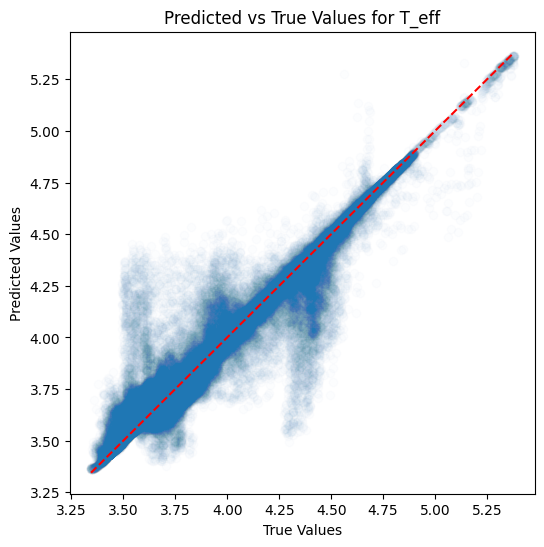

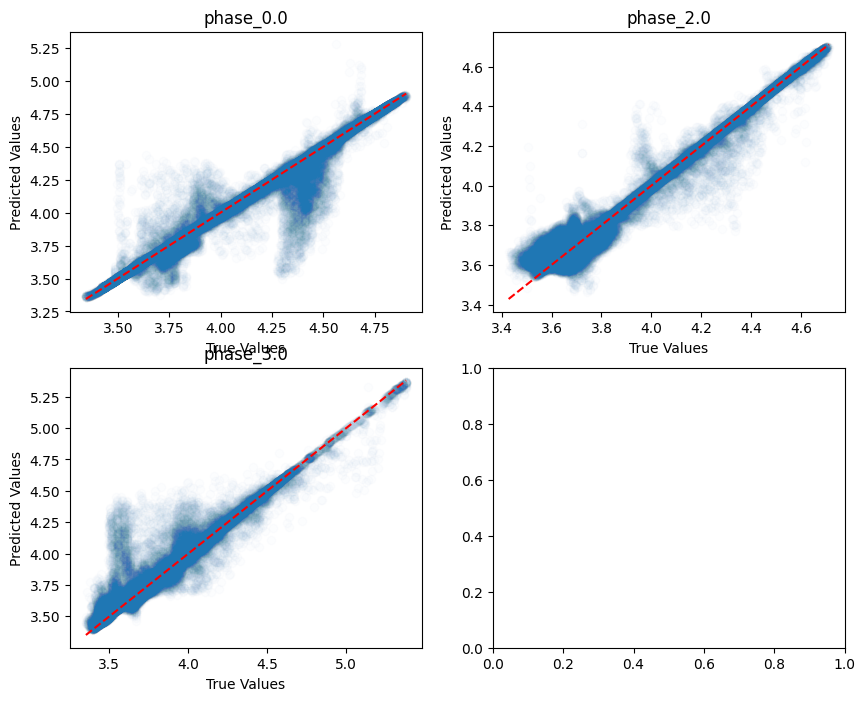

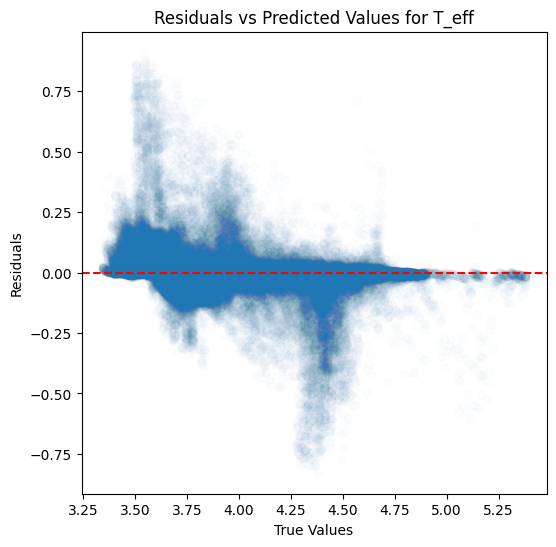

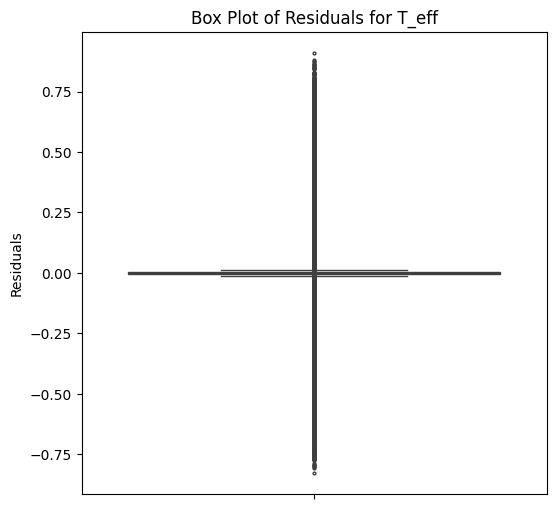

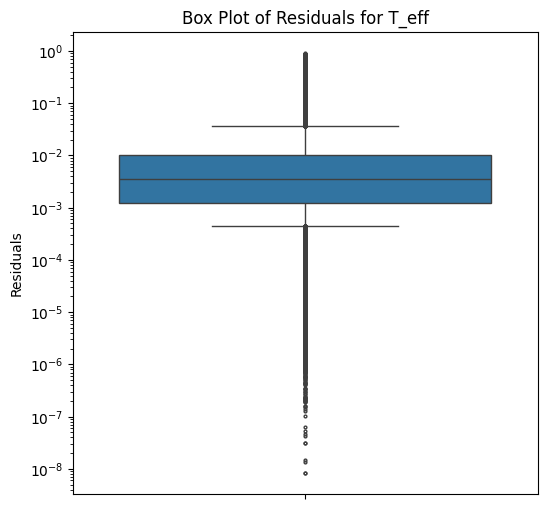

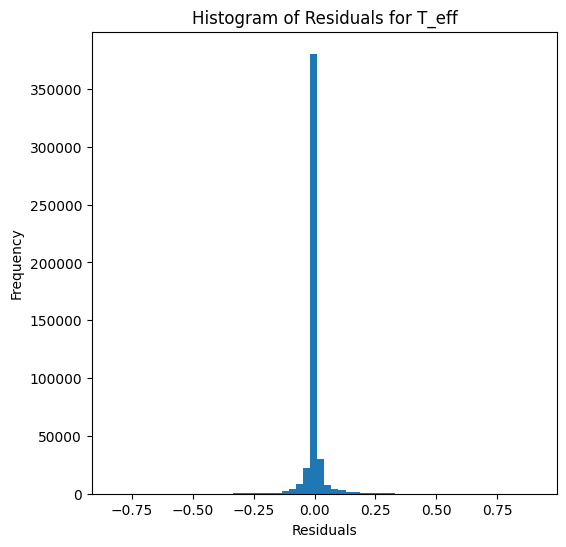

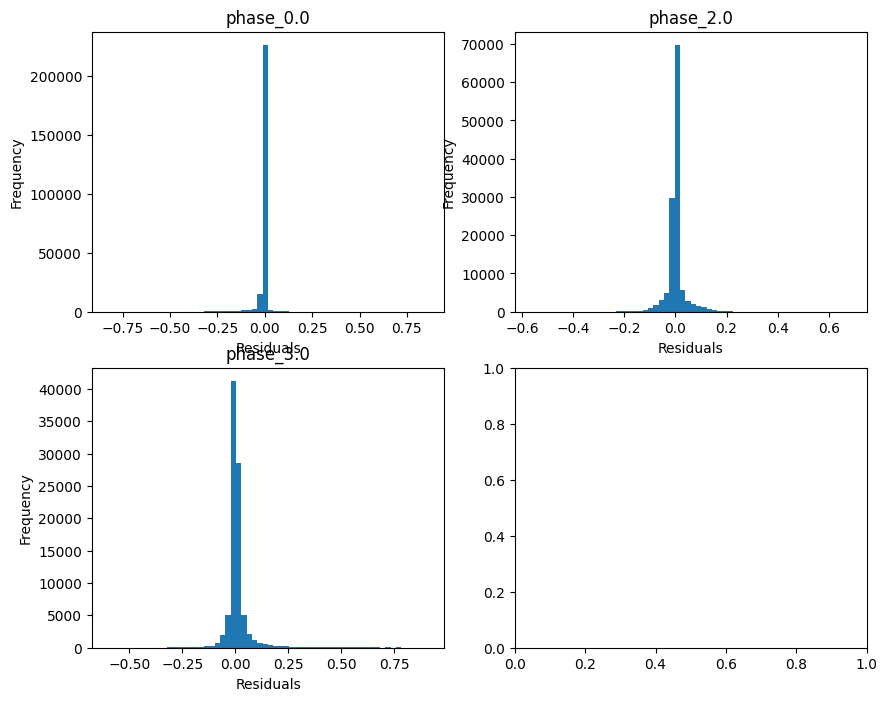

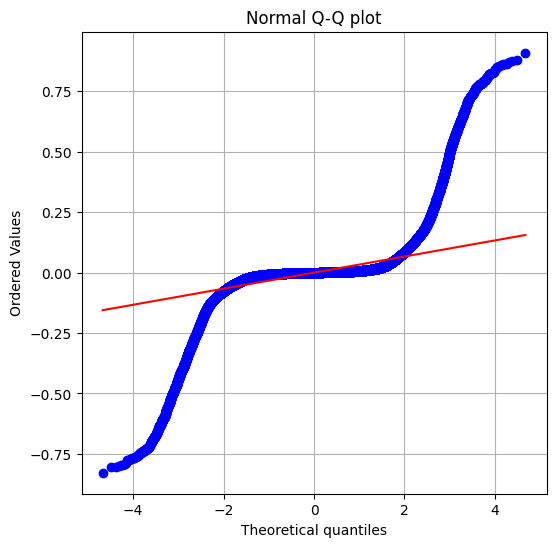

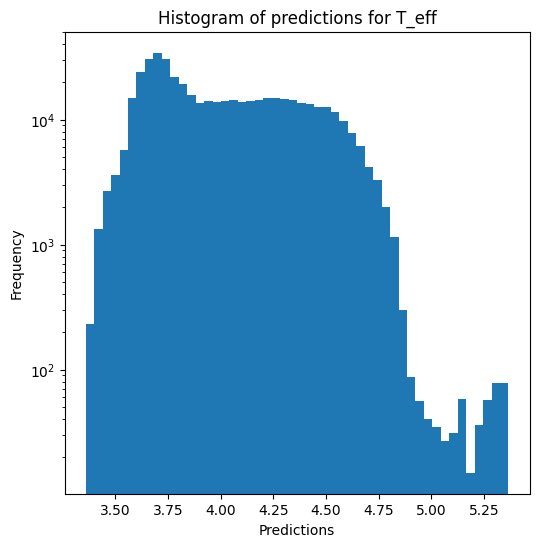

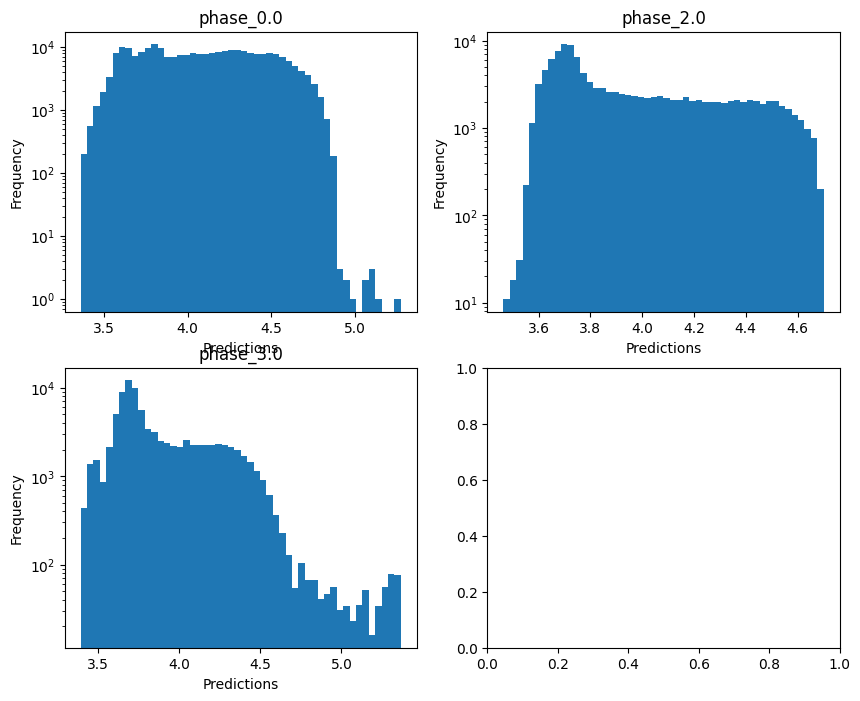


log_g results for the phase category with a value of 0.0
  value range :  -0.5967768342670462 - 5.433070637654307
  RVE :  0.7710301516251565
  RMSE :  0.3041427895771747
  MAE :  0.06807028464450145
  MedAE :  0.006744223727733534
  CORR :  0.902618647992163
  MAX_ER :  5.29024942116914
  Percentiles : 
    75th percentile :  0.02186436330230479
    90th percentile :  0.06807965772094834
    95th percentile :  0.19504388934527844
    99th percentile :  1.6983550656606299

log_g results for the phase category with a value of 2.0
  value range :  -0.2959230723262505 - 4.408311770676233
  RVE :  0.6057118996710145
  RMSE :  0.5721827854686825
  MAE :  0.2536211996158465
  MedAE :  0.02485779212075423
  CORR :  0.7805013950440798
  MAX_ER :  4.309623061355479
  Percentiles : 
    75th percentile :  0.1531363490573906
    90th percentile :  0.9706879535923897
    95th percentile :  1.4659709403008188
    99th percentile :  2.3004863942590963

log_g results for the phase category with a va

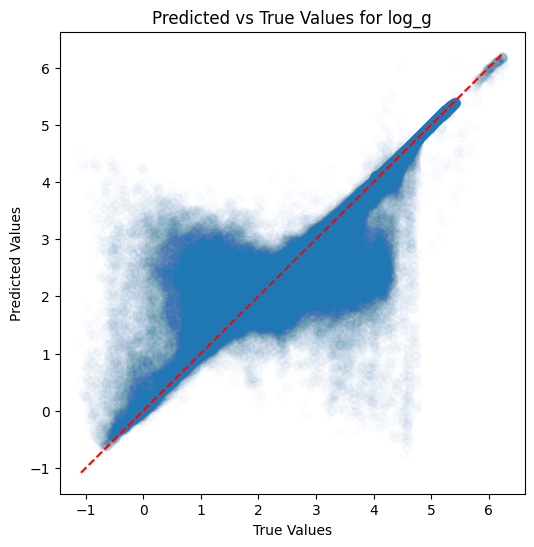

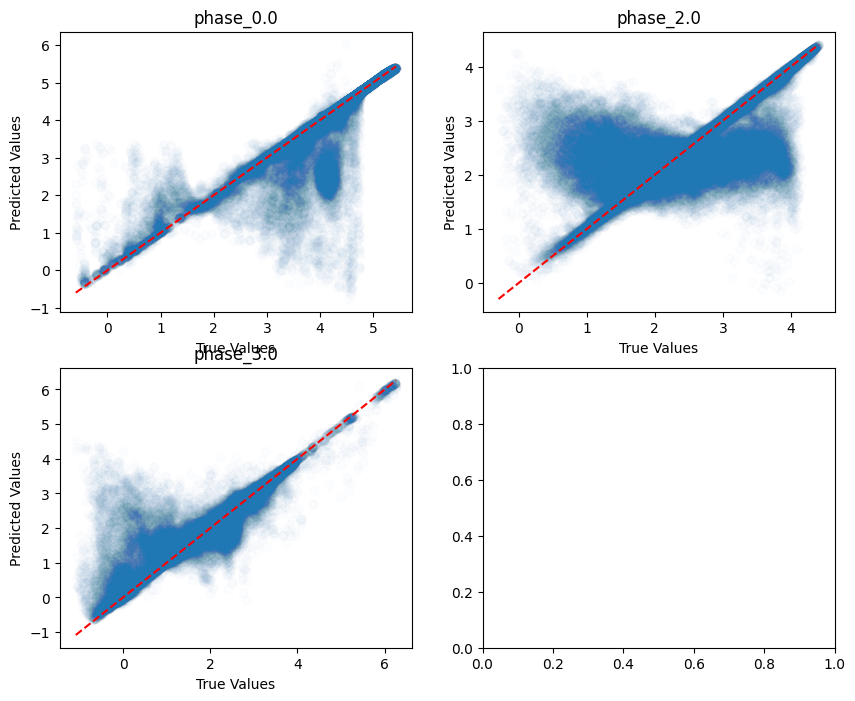

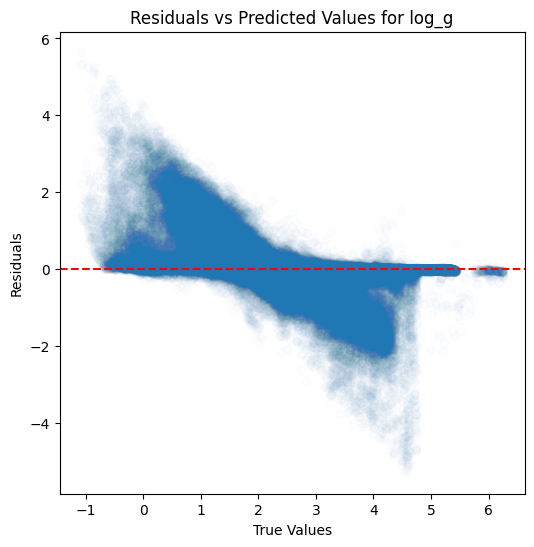

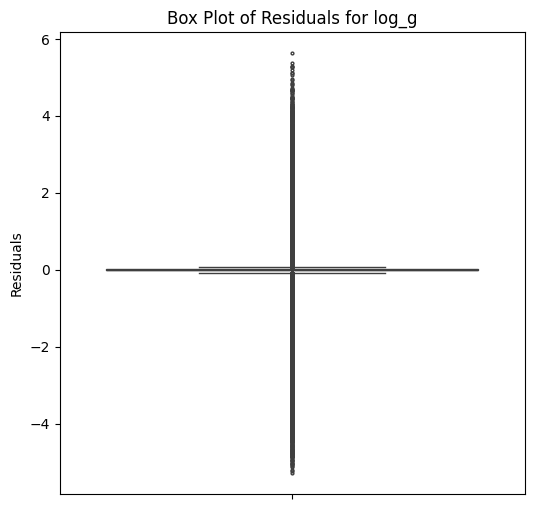

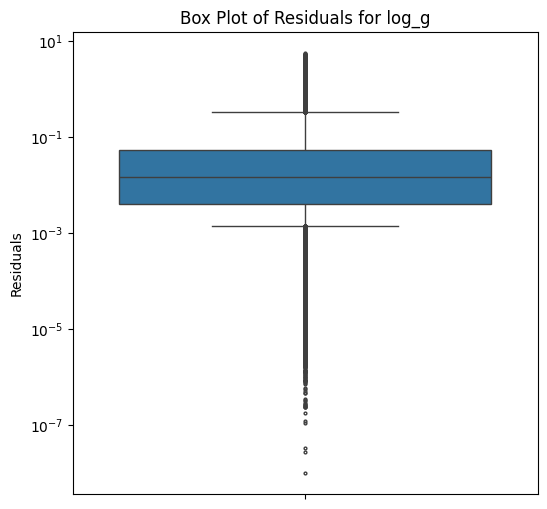

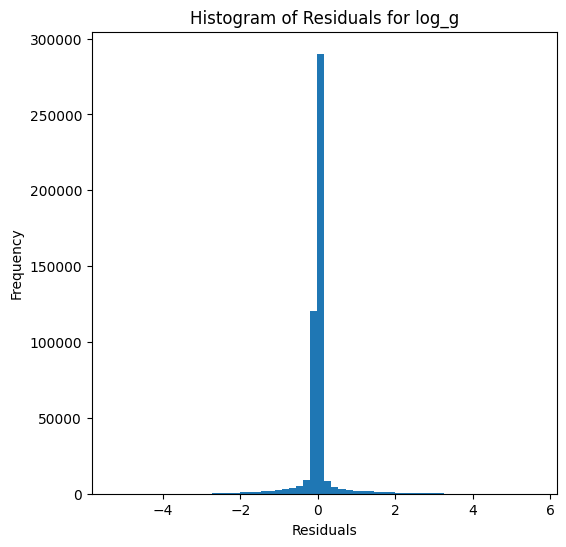

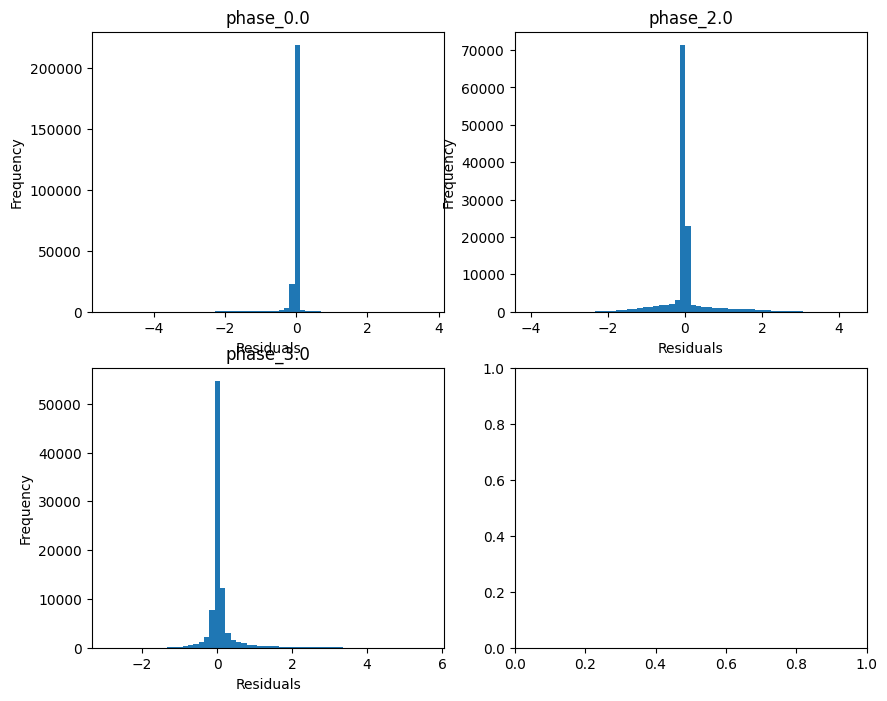

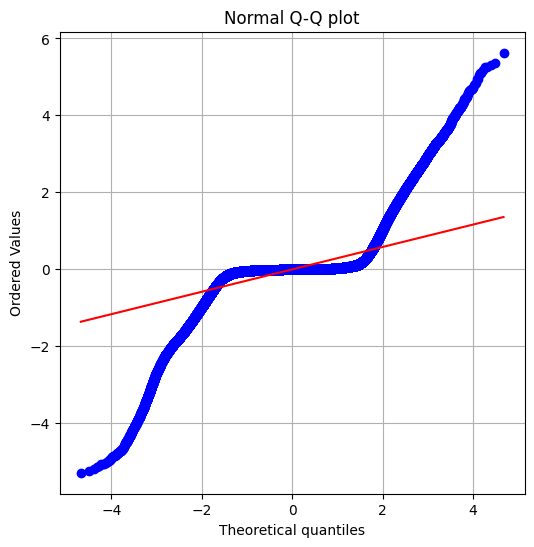

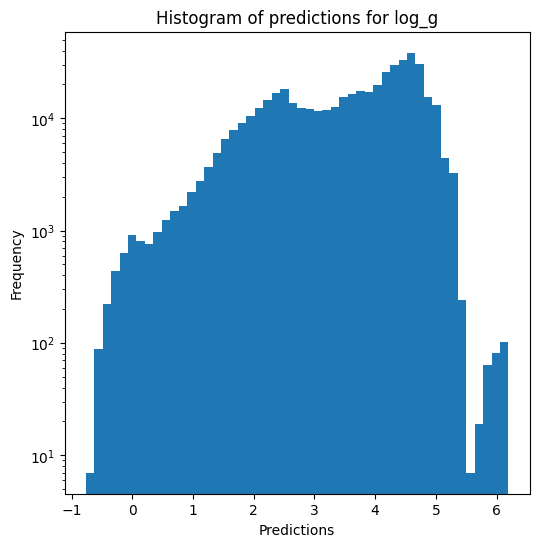

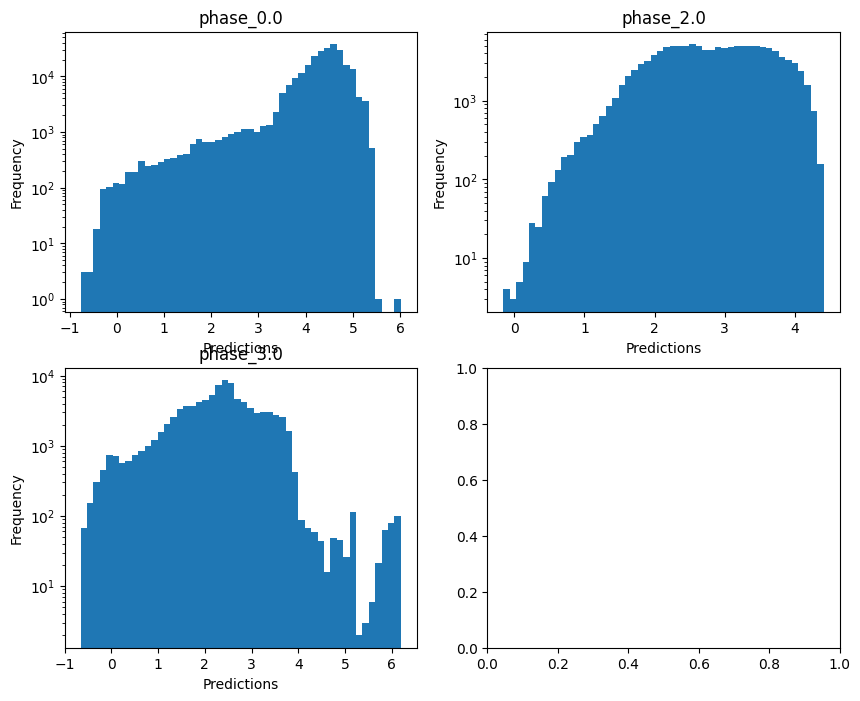

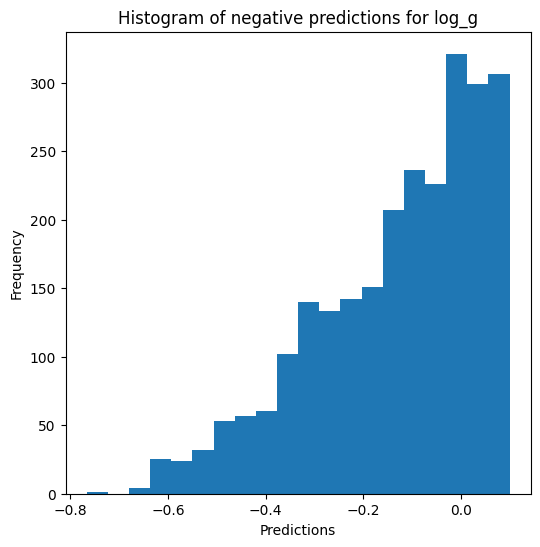


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9307589991907433
  RMSE :  0.15229693416455725
  MAE :  0.035068746654408144
  MedAE :  0.004554499920934471
  CORR :  0.9669391862099925
  MAX_ER :  2.644238689314669
  Percentiles : 
    75th percentile :  0.012818773776975309
    90th percentile :  0.035531195976700916
    95th percentile :  0.09799466960427235
    99th percentile :  0.8496447494128168

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.6608536643250182
  RMSE :  0.2860857595248748
  MAE :  0.12681140946306713
  MedAE :  0.012430794553944802
  CORR :  0.8164740802042095
  MAX_ER :  2.155032047738456
  Percentiles : 
    75th percentile :  0.07659903822057695
    90th percentile :  0.48523897695691115
    95th percentile :  0.7329572302284769
    99th percentile :  1.1503134740644323

radius results for the phase categ

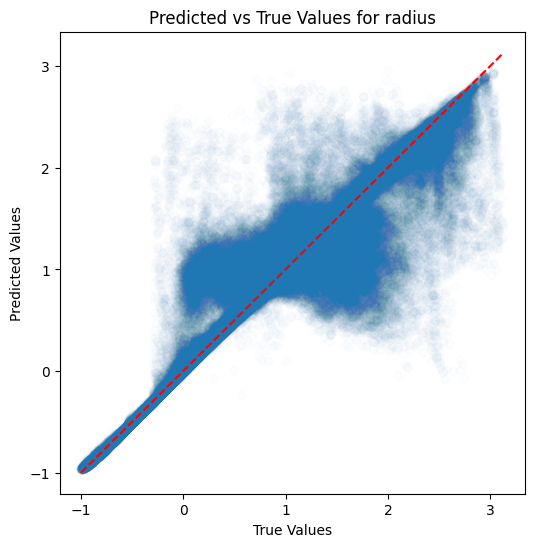

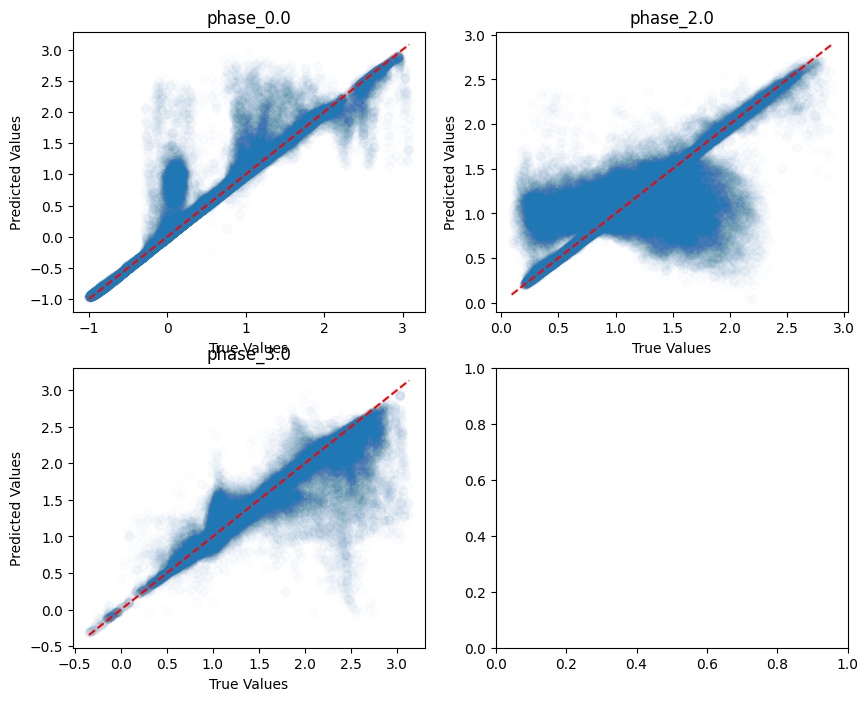

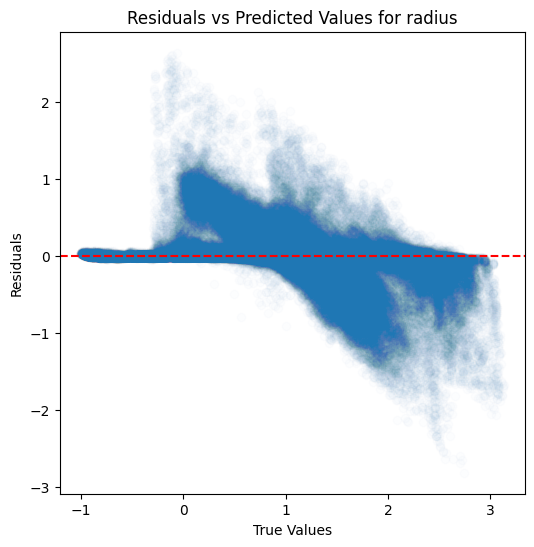

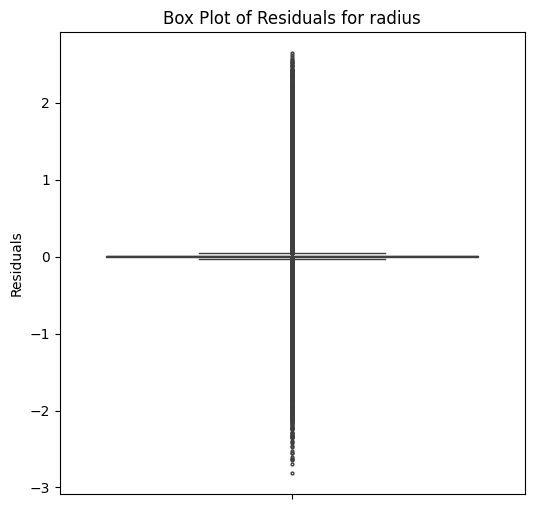

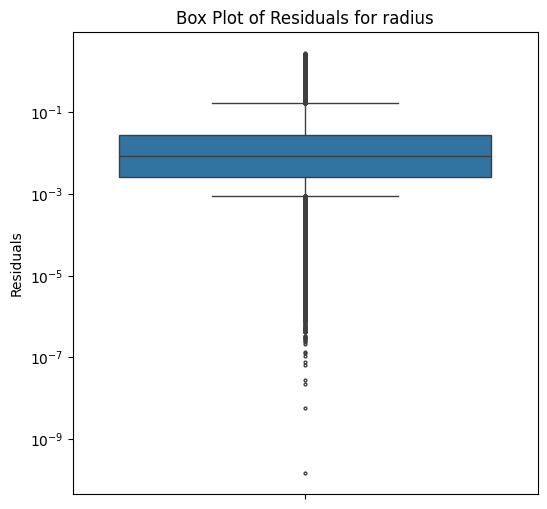

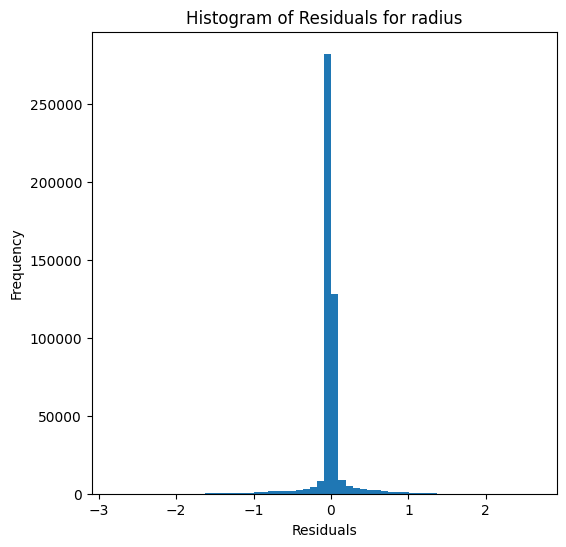

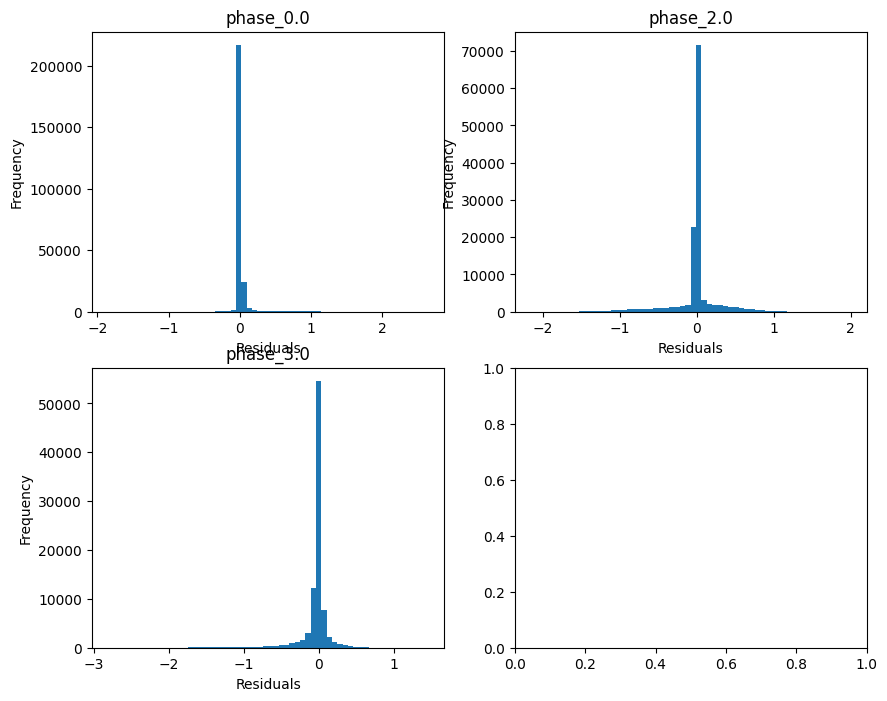

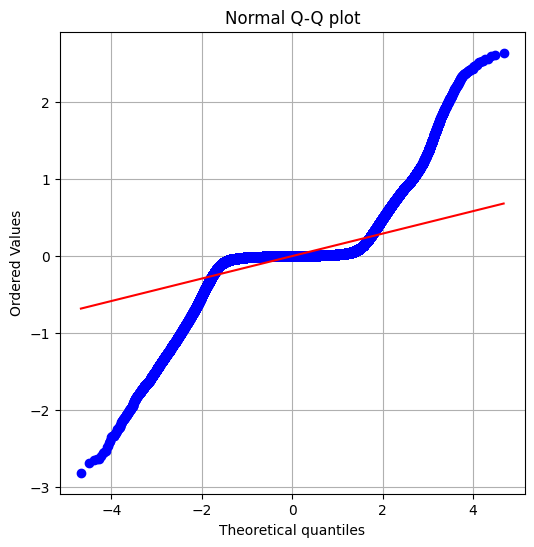

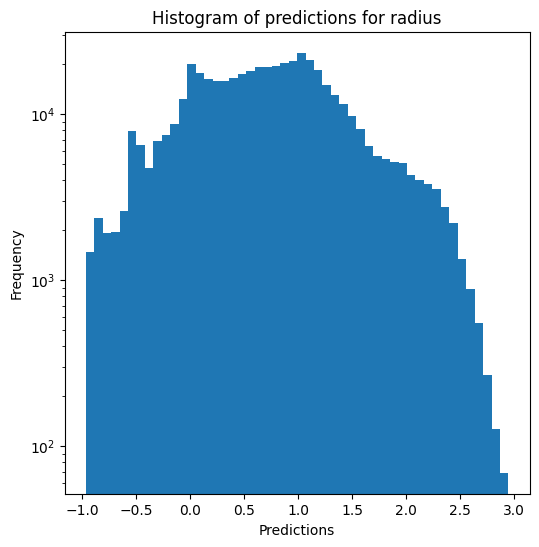

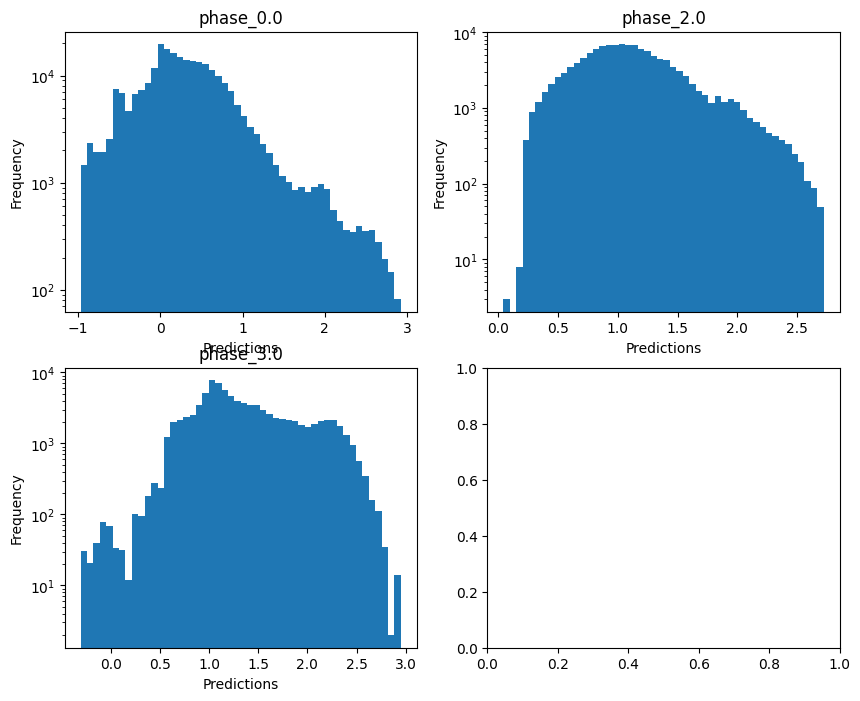

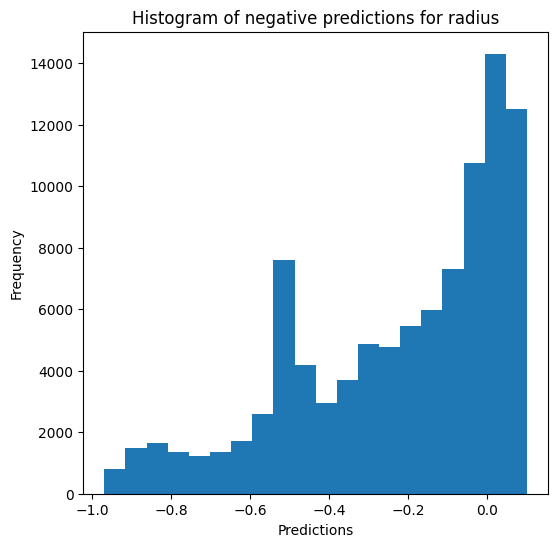

Saving predictions and results...


In [14]:
best_params_RF = {'n_jobs':10, 'n_estimators': 300, 'criterion': 'friedman_mse', 'max_depth': 50, 'min_samples_leaf': 5, 'min_samples_split': 2, 'max_features': 'log2', 'max_leaf_nodes': None}

print(path_to_results)
dt_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
dt_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name="quantile", **best_params_RF)

### K nearest neighbours

In [15]:
tag = "scale_quantile"

#### Testing the uniform weights with brute strength

In [16]:
cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["brute"]
            }

gscv_knn = GridSearchCV(KNeighborsRegressor(n_jobs = 5,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_knn.fit(X_train_quantile, y_train)
display_grid_search(gscv_knn)

Fitting 10 folds for each of 5 candidates, totalling 50 fits
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   7.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   6.4s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   6.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   6.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   6.5s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   6.4s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   6.6s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   6.4s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   6.5s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   6.5s
[CV] END ...algorithm=brute, n_neighbors=10, weights=uniform; total time=   6.6s
[CV] END ...algorithm=brute, n_neighbors=10, wei

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.013130,0.002038,6.736377,0.375437,brute,5,uniform,"{'algorithm': 'brute', 'n_neighbors': 5, 'weig...",-0.238401,-0.230395,-0.231480,-0.235612,-0.232677,-0.227920,-0.231553,-0.231749,-0.243078,-0.227889,-0.233075,0.004498,3,-0.071314,-0.067451,-0.068963,-0.069553,-0.068316,-0.067569,-0.069316,-0.068411,-0.072413,-0.067821,-0.069113,0.001547,1
1,0.014553,0.001210,6.585560,0.084600,brute,10,uniform,"{'algorithm': 'brute', 'n_neighbors': 10, 'wei...",-0.229273,-0.220216,-0.222849,-0.225029,-0.223380,-0.219404,-0.223030,-0.223061,-0.230460,-0.220226,-0.223693,0.003505,1,-0.074470,-0.070460,-0.072276,-0.072386,-0.071499,-0.070721,-0.072824,-0.071803,-0.074870,-0.071251,-0.072256,0.001395,2
2,0.014366,0.000777,6.623258,0.063950,brute,20,uniform,"{'algorithm': 'brute', 'n_neighbors': 20, 'wei...",-0.233448,-0.225648,-0.230271,-0.229789,-0.229129,-0.225187,-0.229327,-0.229647,-0.234730,-0.226349,-0.229353,0.002949,2,-0.086030,-0.081870,-0.084339,-0.084078,-0.083158,-0.082623,-0.084854,-0.083991,-0.086133,-0.083092,-0.084017,0.001322,3
3,0.014052,0.000800,6.583810,0.079422,brute,30,uniform,"{'algorithm': 'brute', 'n_neighbors': 30, 'wei...",-0.241681,-0.235296,-0.240241,-0.239415,-0.237309,-0.234911,-0.238917,-0.238829,-0.243423,-0.236134,-0.238616,0.002618,4,-0.098152,-0.094395,-0.096716,-0.096509,-0.095251,-0.095081,-0.097488,-0.096322,-0.098099,-0.095561,-0.096357,0.001226,4
4,0.012915,0.001142,6.671743,0.098424,brute,50,uniform,"{'algorithm': 'brute', 'n_neighbors': 50, 'wei...",-0.259689,-0.253989,-0.258177,-0.257540,-0.255121,-0.253107,-0.257580,-0.256538,-0.261381,-0.254047,-0.256717,0.002536,5,-0.120605,-0.116747,-0.118759,-0.118434,-0.117530,-0.117398,-0.119947,-0.118433,-0.120126,-0.117920,-0.118590,0.001214,5


Best parameters {'algorithm': 'brute', 'n_neighbors': 10, 'weights': 'uniform'}
Best score -0.22369278127108908


Best parameters {'algorithm': 'brute', 'n_neighbors': 10, 'weights': 'uniform'}

Best score -0.22369278127108908

#### Testing the uniform weights with algorithms

In [17]:
cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 30, 50, 75, 100]
            }

gscv_knn = GridSearchCV(KNeighborsRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_knn.fit(X_train_quantile, y_train)
display_grid_search(gscv_knn)

Fitting 10 folds for each of 50 candidates, totalling 500 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.2s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.4s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.4s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.2s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.3s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.5s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.5s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.4s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.278140,0.022575,1.211508,0.117204,ball_tree,15,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.238400,-0.230394,-0.231480,-0.235611,-0.232677,-0.227920,-0.231552,-0.231749,-0.243078,-0.227889,-0.233075,0.004498,21,-0.071308,-0.067443,-0.068960,-0.069543,-0.068310,-0.067565,-0.069309,-0.068407,-0.072412,-0.067816,-0.069107,0.001548,1
1,0.255744,0.007910,1.414995,0.033953,ball_tree,15,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.229272,-0.220216,-0.222849,-0.225028,-0.223380,-0.219404,-0.223030,-0.223061,-0.230460,-0.220226,-0.223693,0.003505,2,-0.074468,-0.070459,-0.072275,-0.072384,-0.071496,-0.070718,-0.072823,-0.071801,-0.074868,-0.071249,-0.072254,0.001395,12
2,0.268113,0.013624,1.620861,0.159231,ball_tree,15,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.233448,-0.225648,-0.230271,-0.229789,-0.229129,-0.225186,-0.229327,-0.229647,-0.234730,-0.226349,-0.229353,0.002949,18,-0.086030,-0.081871,-0.084340,-0.084078,-0.083158,-0.082622,-0.084854,-0.083991,-0.086133,-0.083092,-0.084017,0.001322,30
3,0.285403,0.022090,1.920185,0.067933,ball_tree,15,30,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.241681,-0.235297,-0.240241,-0.239415,-0.237309,-0.234911,-0.238917,-0.238829,-0.243423,-0.236134,-0.238616,0.002618,36,-0.098152,-0.094396,-0.096716,-0.096508,-0.095251,-0.095081,-0.097488,-0.096322,-0.098099,-0.095561,-0.096357,0.001226,35
4,0.264236,0.003740,2.208912,0.059413,ball_tree,15,50,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.259689,-0.253989,-0.258177,-0.257540,-0.255121,-0.253107,-0.257580,-0.256538,-0.261381,-0.254047,-0.256717,0.002536,45,-0.120605,-0.116747,-0.118759,-0.118434,-0.117530,-0.117398,-0.119947,-0.118433,-0.120126,-0.117920,-0.118590,0.001214,48
5,0.252630,0.015858,1.577063,0.088249,ball_tree,30,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.238400,-0.230394,-0.231481,-0.235611,-0.232677,-0.227920,-0.231552,-0.231749,-0.243078,-0.227888,-0.233075,0.004498,25,-0.071308,-0.067443,-0.068962,-0.069543,-0.068310,-0.067565,-0.069309,-0.068407,-0.072412,-0.067816,-0.069108,0.001548,9
6,0.246831,0.013520,1.743142,0.073136,ball_tree,30,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.229272,-0.220216,-0.222849,-0.225028,-0.223380,-0.219404,-0.223030,-0.223061,-0.230460,-0.220226,-0.223693,0.003505,3,-0.074468,-0.070459,-0.072275,-0.072384,-0.071496,-0.070719,-0.072823,-0.071801,-0.074869,-0.071249,-0.072254,0.001394,13
7,0.242898,0.007802,2.003171,0.102760,ball_tree,30,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.233448,-0.225648,-0.230271,-0.229789,-0.229128,-0.225186,-0.229327,-0.229647,-0.234730,-0.226349,-0.229352,0.002949,13,-0.086030,-0.081871,-0.084340,-0.084078,-0.083157,-0.082622,-0.084854,-0.083992,-0.086133,-0.083092,-0.084017,0.001322,26
8,0.255494,0.014580,2.236806,0.107899,

Best parameters {'algorithm': 'kd_tree', 'leaf_size': 15, 'n_neighbors': 10, 'weights': 'uniform'}
Best score -0.22369250320436365


Best parameters {'algorithm': 'kd_tree', 'leaf_size': 15, 'n_neighbors': 10, 'weights': 'uniform'}

Best score -0.22369250320436365

the algorithms give almost the same results then brute force with much less time. It is better to use them with distance calculation

#### Testing the distance weights with algorithms

In [18]:
cv_params = {'n_neighbors' : [5, 25, 50],
             'weights' : ["distance"],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 50, 100],
             'p' : [1.0, 1.3, 1.6, 2.0]
            }

gscv_knn_1 = GridSearchCV(KNeighborsRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_knn_1.fit(X_train_quantile, y_train)
display_grid_search(gscv_knn_1)

Fitting 10 folds for each of 72 candidates, totalling 720 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.1s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.4s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.1s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.1s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.2s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.5s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.4s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.2s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.2s
[CV] END a

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_p,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.298614,0.024767,1.078319,0.125292,ball_tree,15,5,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.281500,-0.271724,-0.275315,-0.279287,-0.275223,-0.269589,-0.277361,-0.274768,-0.286013,-0.268423,-0.275920,0.005123,50,-0.081875,-0.077195,-0.079354,-0.080128,-0.078421,-0.077156,-0.080306,-0.078531,-0.083134,-0.077572,-0.079367,0.001907,20
1,0.522235,0.024000,1.815558,0.137220,ball_tree,15,5,1.3,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.281508,-0.271722,-0.275317,-0.279355,-0.275230,-0.269593,-0.277363,-0.274763,-0.286018,-0.268423,-0.275929,0.005129,55,-0.081870,-0.077178,-0.079344,-0.080136,-0.078417,-0.077150,-0.080303,-0.078514,-0.083131,-0.077560,-0.079360,0.001911,13
2,0.499511,0.012400,2.001736,0.142791,ball_tree,15,5,1.6,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.281516,-0.271722,-0.275313,-0.279355,-0.275250,-0.269592,-0.277363,-0.274763,-0.286015,-0.268415,-0.275930,0.005131,61,-0.081885,-0.077174,-0.079337,-0.080131,-0.078421,-0.077145,-0.080297,-0.078508,-0.083120,-0.077549,-0.079357,0.001912,7
3,0.265679,0.009382,1.251564,0.036499,ball_tree,15,5,2.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.281516,-0.271727,-0.275326,-0.279360,-0.275251,-0.269584,-0.277363,-0.274752,-0.286015,-0.268415,-0.275931,0.005132,67,-0.081885,-0.077182,-0.079343,-0.080136,-0.078421,-0.077134,-0.080298,-0.078494,-0.083119,-0.077551,-0.079356,0.001913,1
4,0.284316,0.017901,1.692644,0.155143,ball_tree,15,25,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.263346,-0.253288,-0.258754,-0.260545,-0.256978,-0.253507,-0.259624,-0.258655,-0.265678,-0.252393,-0.258277,0.004144,2,-0.087677,-0.082775,-0.085431,-0.085747,-0.084013,-0.083401,-0.086501,-0.084903,-0.088282,-0.083761,-0.085249,0.001742,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,0.285411,0.008058,0.529988,0.020456,kd_tree,100,25,2.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.263544,-0.253566,-0.258981,-0.261001,-0.257275,-0.253603,-0.259723,-0.258715,-0.266000,-0.252673,-0.258508,0.004165,19,-0.087697,-0.082813,-0.085438,-0.085835,-0.084028,-0.083389,-0.086460,-0.084871,-0.088314,-0.083766,-0.085261,0.001745,43
68,0.324449,0.040005,0.824352,0.105093,kd_tree,100,50,1.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.263385,-0.253772,-0.259077,-0.260921,-0.257180,-0.253807,-0.260161,-0.258661,-0.265399,-0.253498,-0.258586,0.003892,29,-0.097175,-0.092379,-0.094780,-0.095098,-0.093579,-0.092922,-0.096109,-0.094272,-0.097608,-0.093570,-0.094749,0.001672,53
69,0.304436,0.028980,1.067211,0.059256,kd_tree,100,50,1.3,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.263552,-0.254002,-0.259425,-0.261268,-0.257354,-0.254069,-0.260356,-0.258889,-0.2657

Best parameters {'algorithm': 'kd_tree', 'leaf_size': 100, 'n_neighbors': 25, 'p': 1.0, 'weights': 'distance'}
Best score -0.25827694370678955


Best parameters {'algorithm': 'kd_tree', 'leaf_size': 100, 'n_neighbors': 25, 'p': 1.0, 'weights': 'distance'}

Best score -0.25827694370678955

In [19]:
cv_params = {'n_neighbors' : [5, 25, 50],
             'weights' : [gaussian],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 50, 100]
            }

gscv_knn_2 = GridSearchCV(KNeighborsRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_knn_2.fit(X_train_quantile, y_train)
display_grid_search(gscv_knn_2)

Fitting 10 folds for each of 18 candidates, totalling 180 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x00000284A0365080>; total time=   1.5s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x00000284A0365080>; total time=   1.5s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x00000284A0365080>; total time=   1.5s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x00000284A0365080>; total time=   1.4s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x00000284A0365080>; total time=   1.5s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x00000284A0365080>; total time=   1.4s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=<function gaussian at 0x00000284A0365080>; total time=   1.6s
[CV] END algorithm=ball_tree, leaf

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.275309,0.016256,1.258947,0.097599,ball_tree,15,5,<function gaussian at 0x00000284A0365080>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.238400,-0.230394,-0.231480,-0.235611,-0.232677,-0.227920,-0.231552,-0.231749,-0.243078,-0.227889,-0.233075,0.004498,1,-0.071308,-0.067443,-0.068960,-0.069543,-0.068310,-0.067565,-0.069309,-0.068407,-0.072412,-0.067816,-0.069107,0.001548,1
1,0.269435,0.008885,1.734947,0.157091,ball_tree,15,25,<function gaussian at 0x00000284A0365080>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.237341,-0.230296,-0.235200,-0.234338,-0.233106,-0.229839,-0.233723,-0.234203,-0.238664,-0.231329,-0.233804,0.002705,9,-0.092036,-0.088124,-0.090517,-0.090175,-0.089229,-0.088781,-0.091009,-0.090075,-0.091866,-0.089277,-0.090109,0.001223,9
2,0.269330,0.026341,2.346773,0.106626,ball_tree,15,50,<function gaussian at 0x00000284A0365080>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.259688,-0.253987,-0.258175,-0.257538,-0.255119,-0.253105,-0.257578,-0.256536,-0.261379,-0.254045,-0.256715,0.002536,15,-0.120604,-0.116746,-0.118757,-0.118433,-0.117528,-0.117397,-0.119946,-0.118431,-0.120125,-0.117919,-0.118589,0.001214,17
3,0.256206,0.027425,1.642019,0.101098,ball_tree,50,5,<function gaussian at 0x00000284A0365080>,"{'algorithm': 'ball_tree', 'leaf_size': 50, 'n...",-0.238400,-0.230394,-0.231481,-0.235611,-0.232677,-0.227920,-0.231552,-0.231749,-0.243078,-0.227888,-0.233075,0.004498,4,-0.071308,-0.067443,-0.068962,-0.069543,-0.068310,-0.067565,-0.069309,-0.068407,-0.072412,-0.067815,-0.069108,0.001548,6
4,0.243619,0.009087,2.250060,0.090822,ball_tree,50,25,<function gaussian at 0x00000284A0365080>,"{'algorithm': 'ball_tree', 'leaf_size': 50, 'n...",-0.237341,-0.230296,-0.235200,-0.234338,-0.233106,-0.229839,-0.233723,-0.234203,-0.238664,-0.231329,-0.233804,0.002705,12,-0.092036,-0.088125,-0.090517,-0.090176,-0.089229,-0.088781,-0.091009,-0.090075,-0.091867,-0.089277,-0.090109,0.001223,12
5,0.253965,0.014420,2.642435,0.185552,ball_tree,50,50,<function gaussian at 0x00000284A0365080>,"{'algorithm': 'ball_tree', 'leaf_size': 50, 'n...",-0.259688,-0.253987,-0.258175,-0.257538,-0.255119,-0.253105,-0.257578,-0.256536,-0.261379,-0.254045,-0.256715,0.002536,14,-0.120604,-0.116746,-0.118757,-0.118433,-0.117528,-0.117397,-0.119946,-0.118431,-0.120125,-0.117919,-0.118589,0.001214,15
6,0.238414,0.017666,2.170132,0.185736,ball_tree,100,5,<function gaussian at 0x00000284A0365080>,"{'algorithm': 'ball_tree', 'leaf_size': 100, '...",-0.238400,-0.230393,-0.231480,-0.235612,-0.232677,-0.227921,-0.231550,-0.231752,-0.243078,-0.227888,-0.233075,0.004498,5,-0.071308,-0.067443,-0.068960,-0.069543,-0.068308,-0.067569,-0.069308,-0.068410,-0.072412,-0.067815,-0.069107,0.001547,3
7,0.229777,0.009530,2.600319,0.281672,ball_tree,100,25,<function gaussian at 0x00000284A0365080>,"{'algorithm': 'ball_tree', 'leaf_size': 100, '...",-0.237341,-0.

Best parameters {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 5, 'weights': <function gaussian at 0x00000284A0365080>}
Best score -0.23307486565818186


Best parameters {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 5, 'weights': <function gaussian at 0x00000284A0365080>}

Best score -0.23307486565818186

#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../results/model_B/fine_tuned_models/

scale_quantile train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

T_eff results for the phase category with a value of 0.0
  value range :  3.344668191350628 - 4.90340707004253
  RVE :  0.9816102820208721
  RMSE :  0.047865836920878306
  MAE :  0.009996450164386245
  MedAE :  0.001536538905448026
  CORR :  0.9908071583787337
  MAX_ER :  0.874798111281978
  Percentiles : 
    75th percentile :  0.003307073299997132
    90th percentile :  0.007861986933777668
    95th percentile :  0.0230896005127836
    99th percentile :  0.24735638135477273

T_eff results for the phase category with a value of 2.0
  value range :  3.42785685311742 - 4.711472733477716
  RVE :  0.9864903774586335
  RMSE :  0.03678460202833876
  MAE :  0.016794588326787745
  MedAE :  0.003710565523524778
  CORR :  0.9932350111353788
  MAX_ER :  0.7014065205935989
  Percentiles : 
    75th percentile :  0.01443164

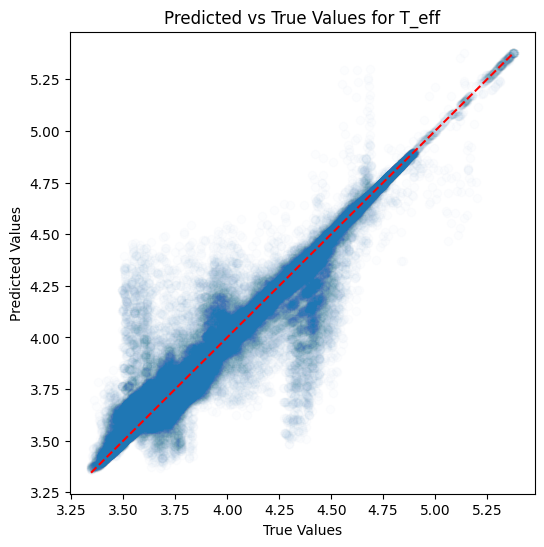

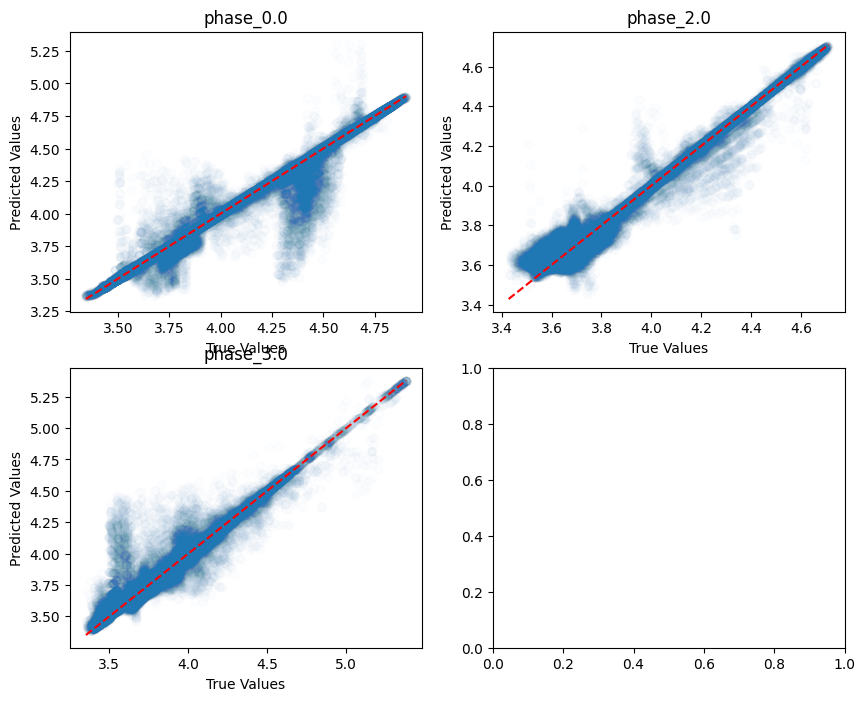

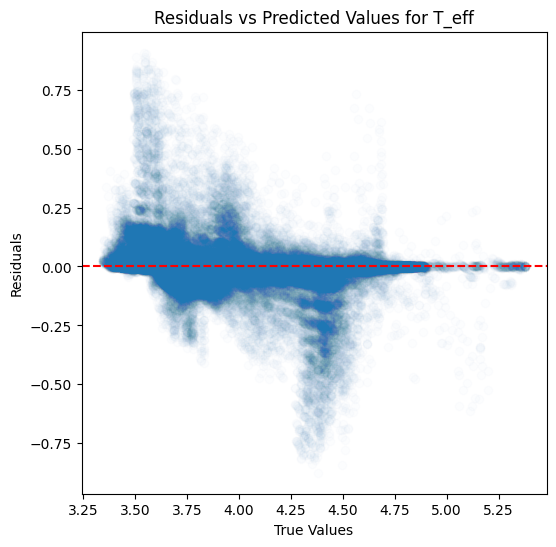

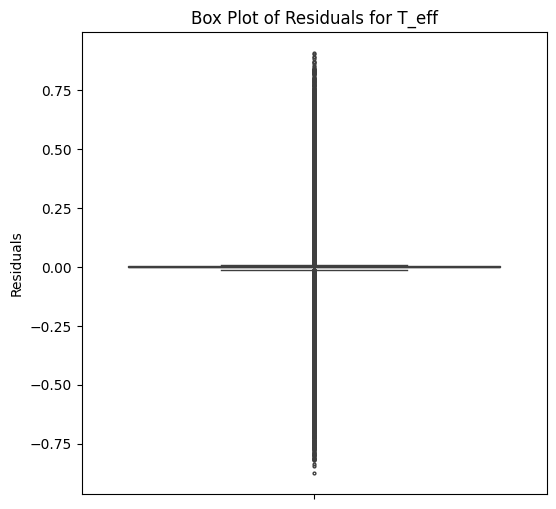

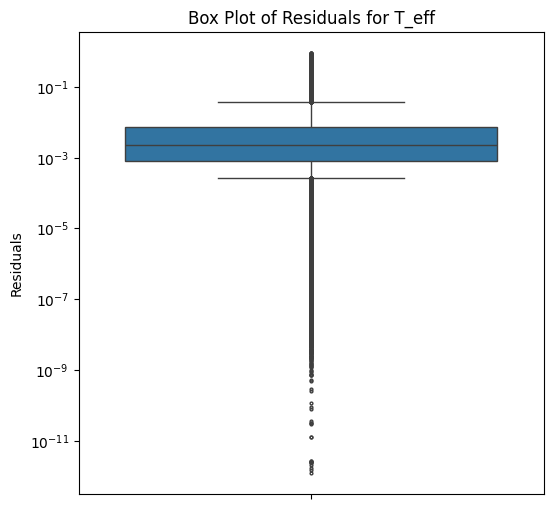

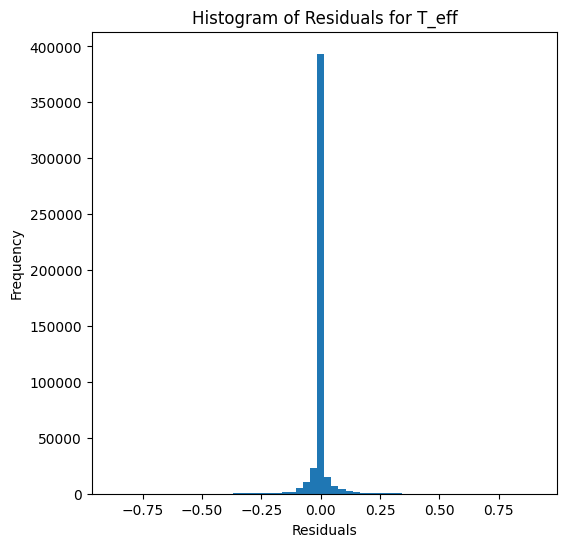

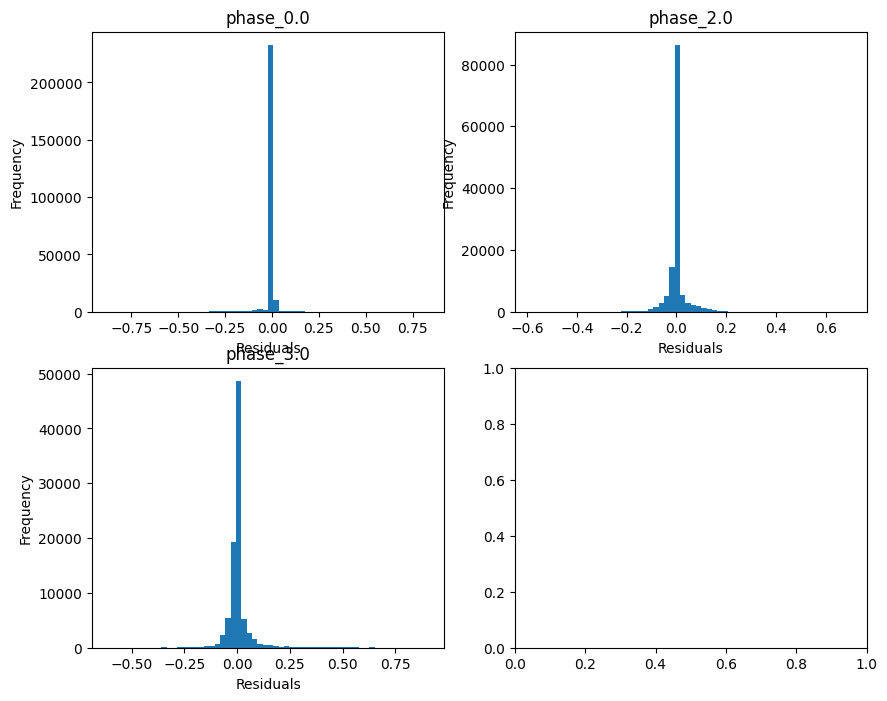

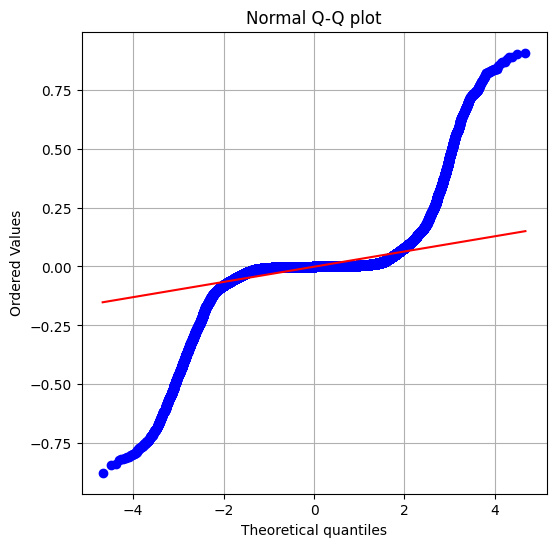

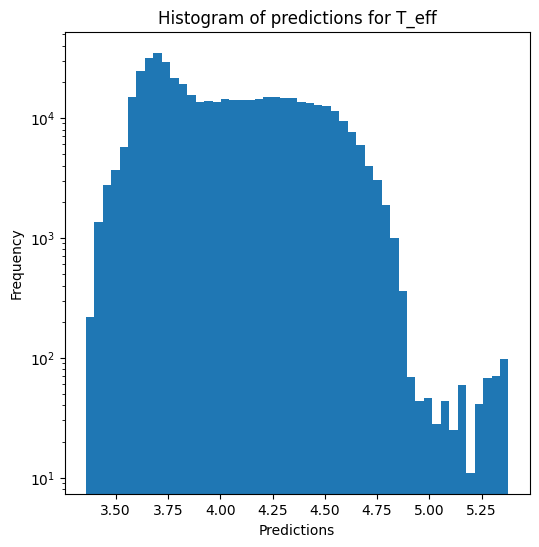

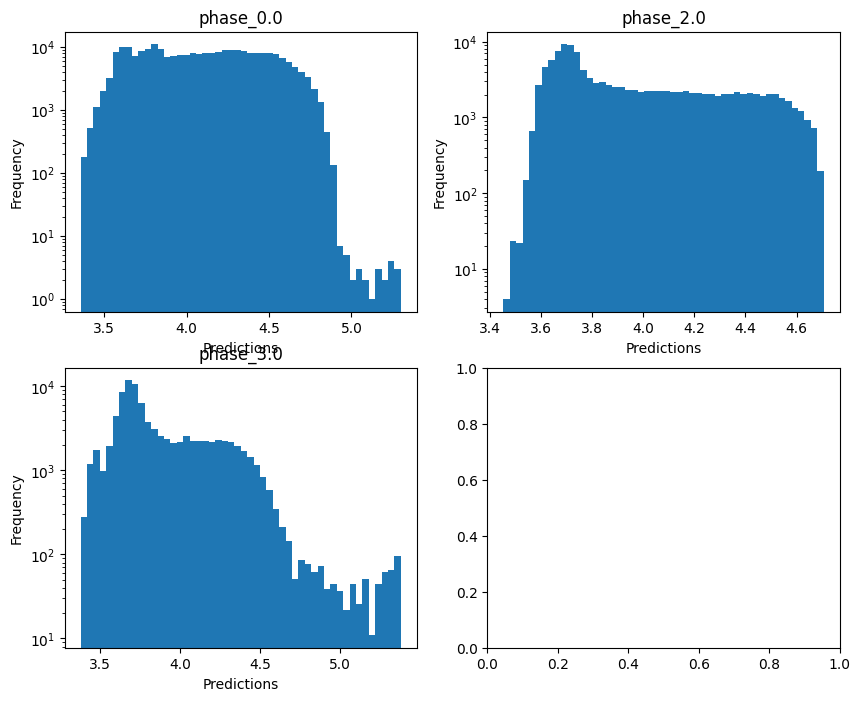


log_g results for the phase category with a value of 0.0
  value range :  -0.5967768342670462 - 5.433070637654307
  RVE :  0.733086966677364
  RMSE :  0.32674149064444674
  MAE :  0.06367152527711856
  MedAE :  0.0034580733319580226
  CORR :  0.889589010272886
  MAX_ER :  5.533463564031843
  Percentiles : 
    75th percentile :  0.01144159253336885
    90th percentile :  0.029540765216387318
    95th percentile :  0.10413983642932925
    99th percentile :  1.7631207036661167

log_g results for the phase category with a value of 2.0
  value range :  -0.2959230723262505 - 4.408311770676233
  RVE :  0.6463118509909351
  RMSE :  0.5415445161531544
  MAE :  0.2408549580111985
  MedAE :  0.018183135995669453
  CORR :  0.8048465558276949
  MAX_ER :  4.362015762404008
  Percentiles : 
    75th percentile :  0.1642316284871289
    90th percentile :  0.93326227682703
    95th percentile :  1.3967220362371613
    99th percentile :  2.1397521565237128

log_g results for the phase category with a 

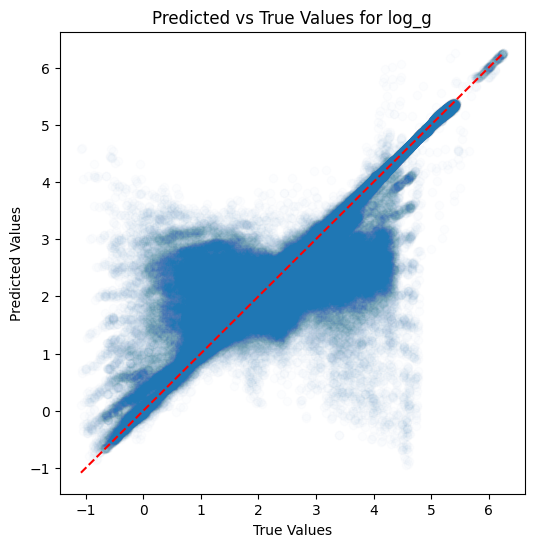

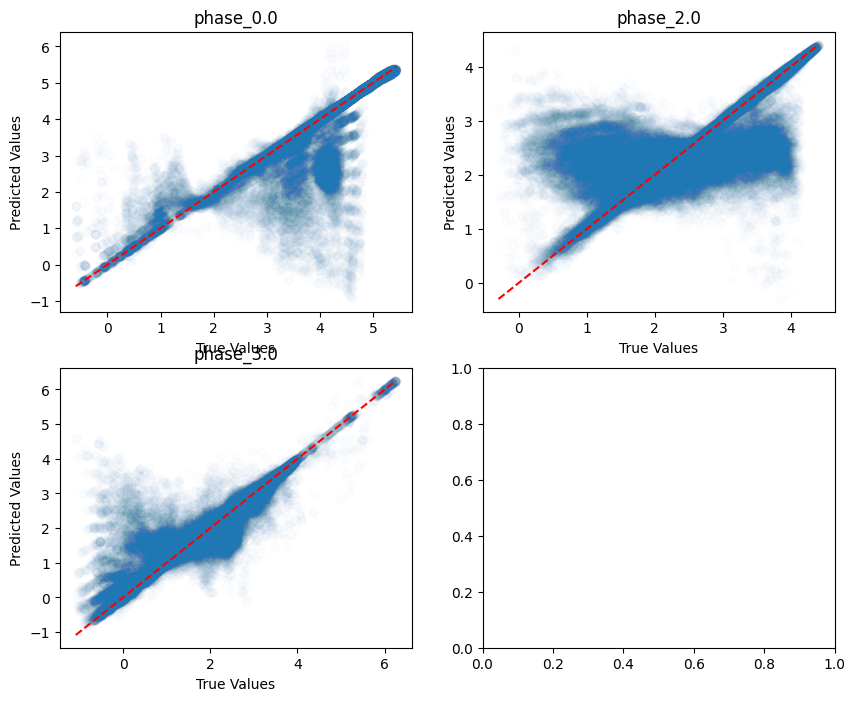

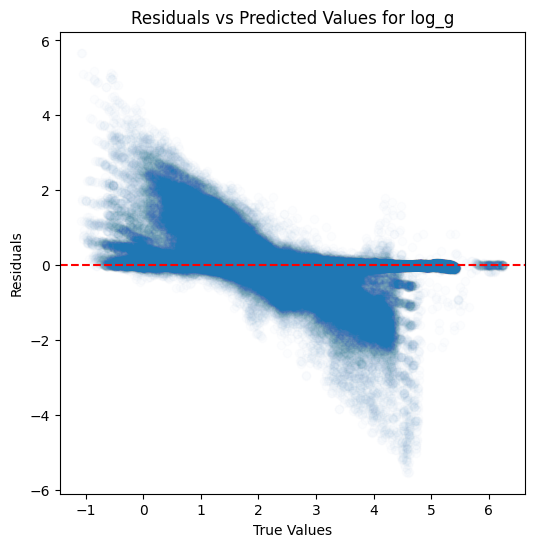

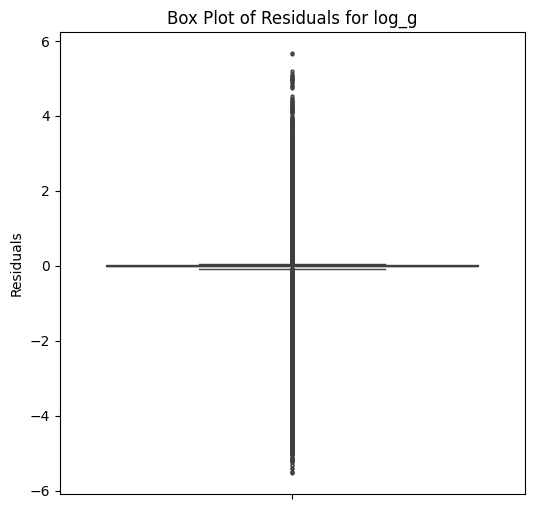

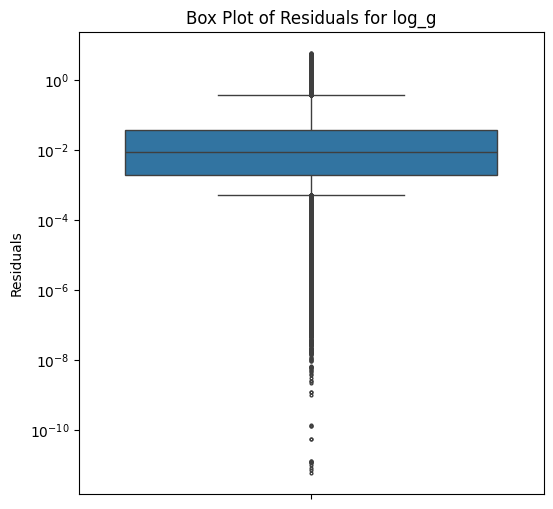

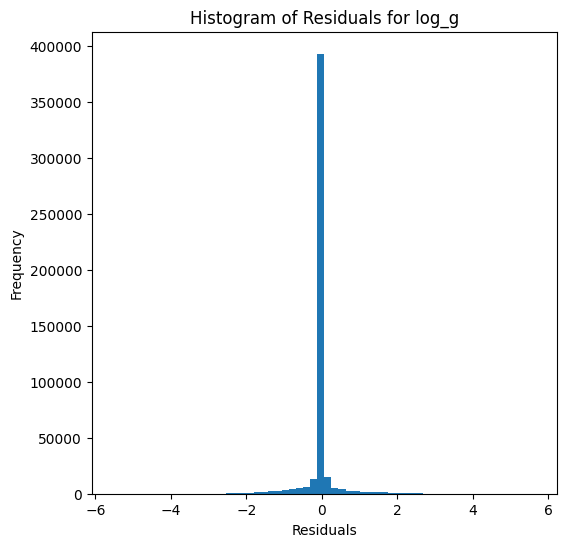

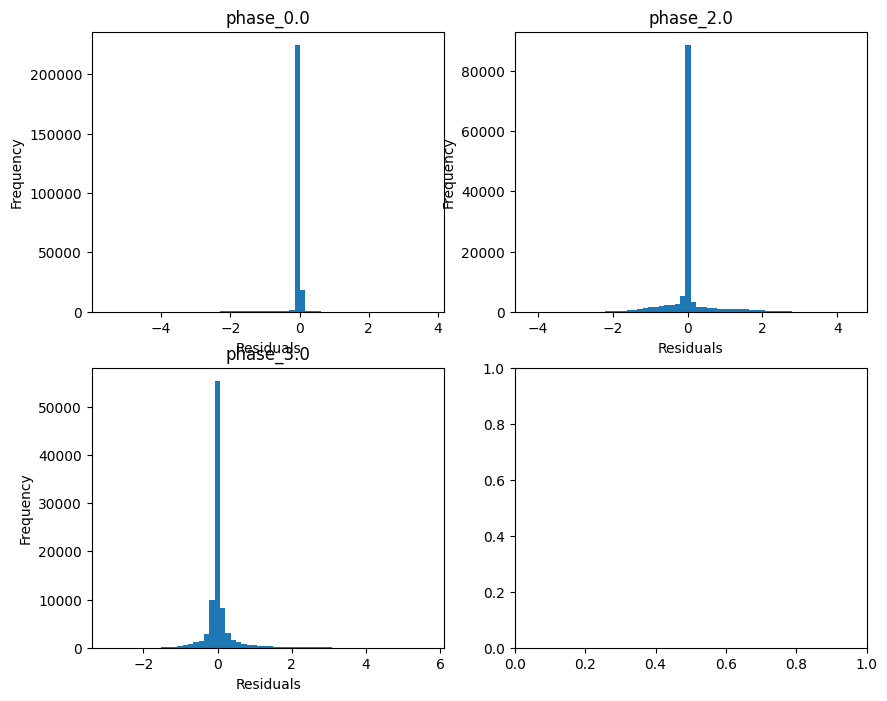

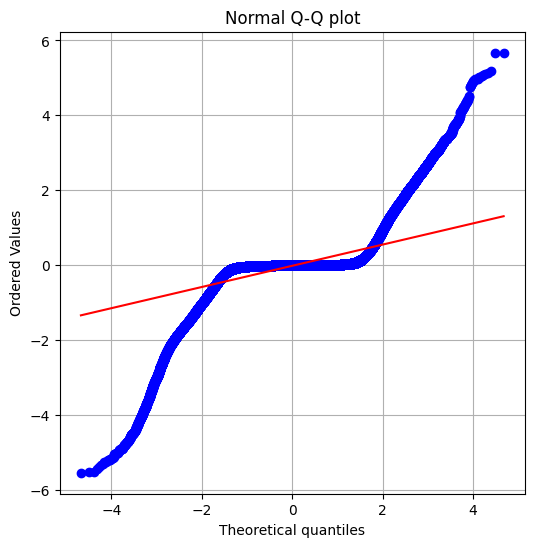

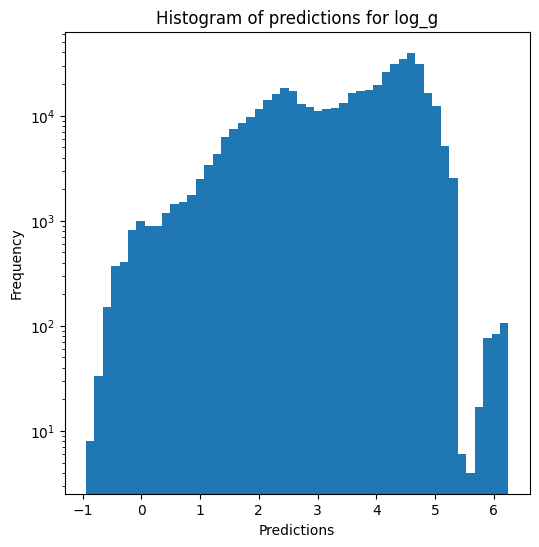

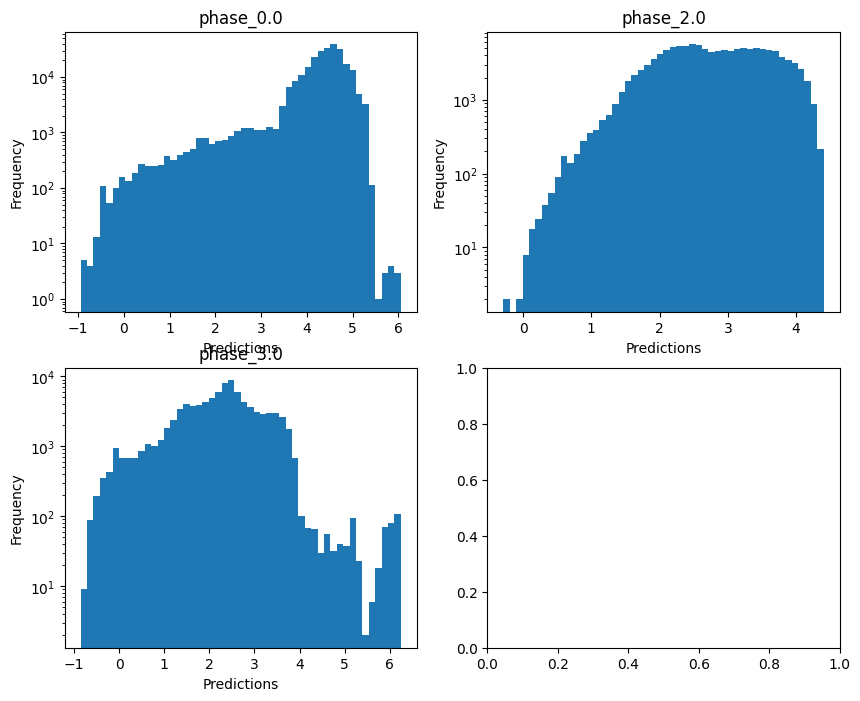

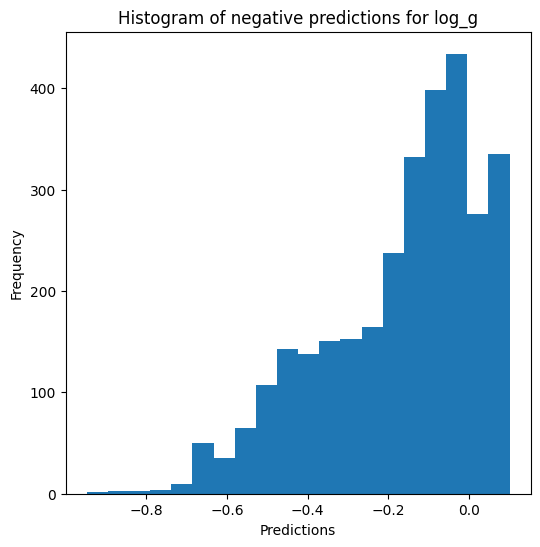


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9191473001373259
  RMSE :  0.16377112087954332
  MAE :  0.03390143532030948
  MedAE :  0.003201646603473357
  CORR :  0.9617373249212098
  MAX_ER :  2.7695500306700653
  Percentiles : 
    75th percentile :  0.008280174169839838
    90th percentile :  0.02080577233072051
    95th percentile :  0.07164995978684194
    99th percentile :  0.8828235500757905

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.6957632272625008
  RMSE :  0.27077156170980865
  MAE :  0.12044009935608971
  MedAE :  0.009110623440676369
  CORR :  0.8357906491867154
  MAX_ER :  2.181332445278503
  Percentiles : 
    75th percentile :  0.0821452991739956
    90th percentile :  0.466627670362829
    95th percentile :  0.6983842117828382
    99th percentile :  1.0698651692909908

radius results for the phase category

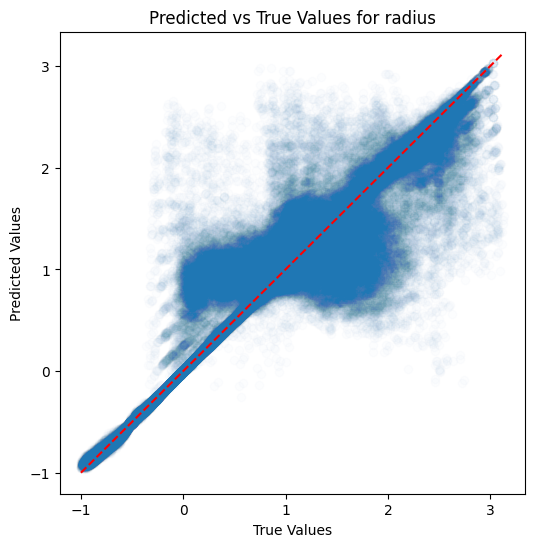

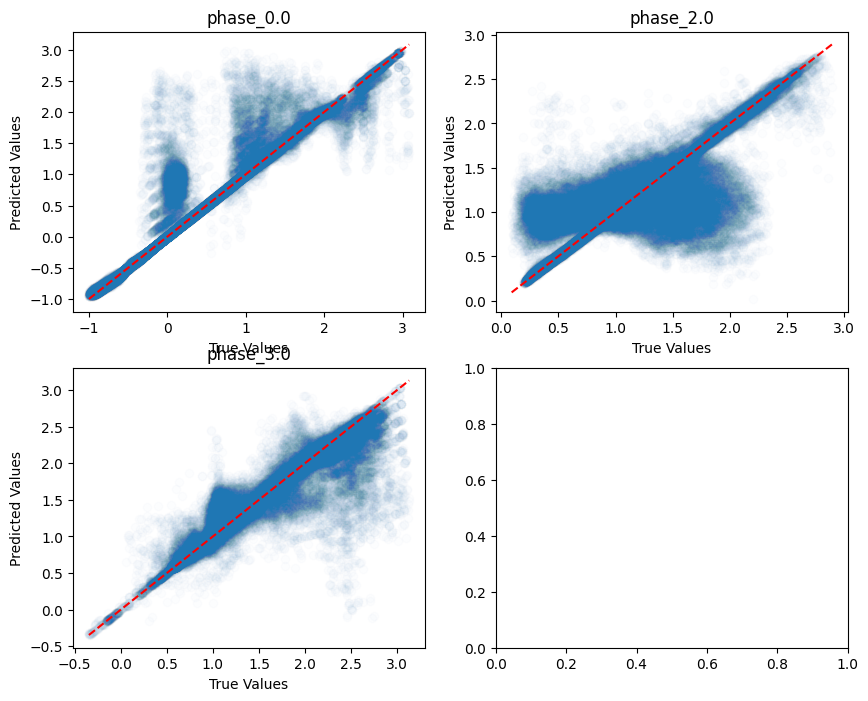

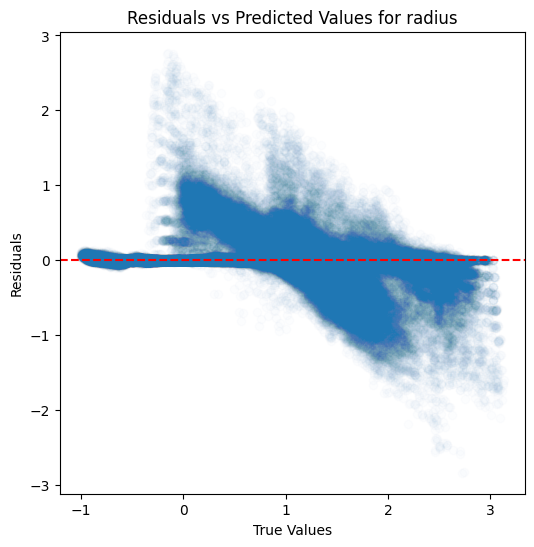

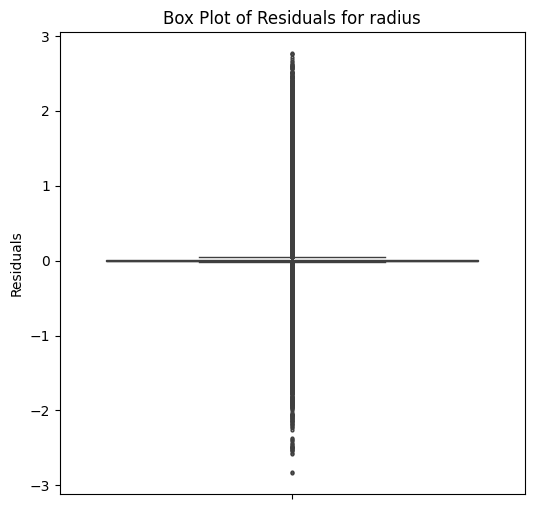

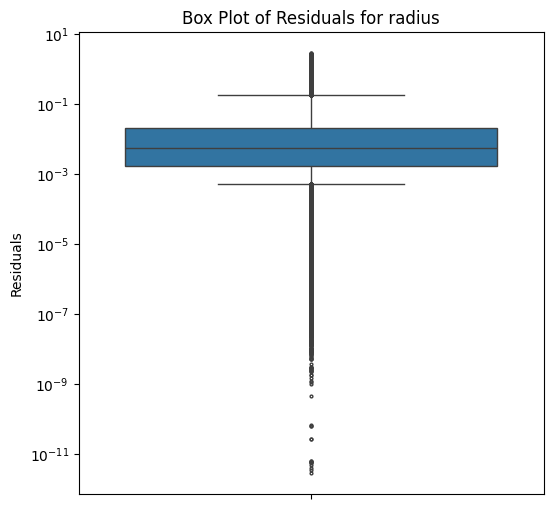

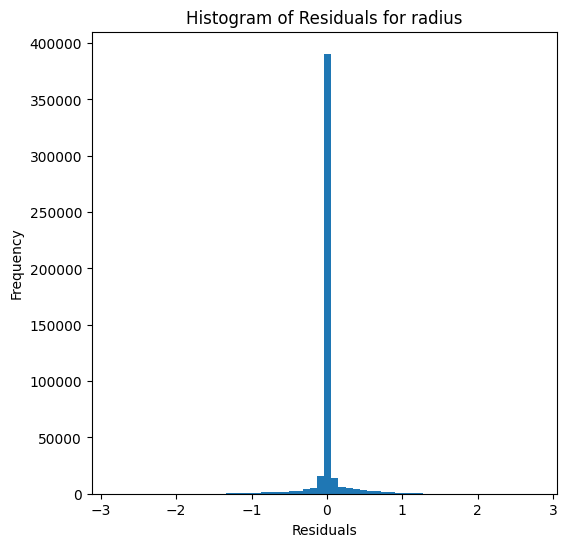

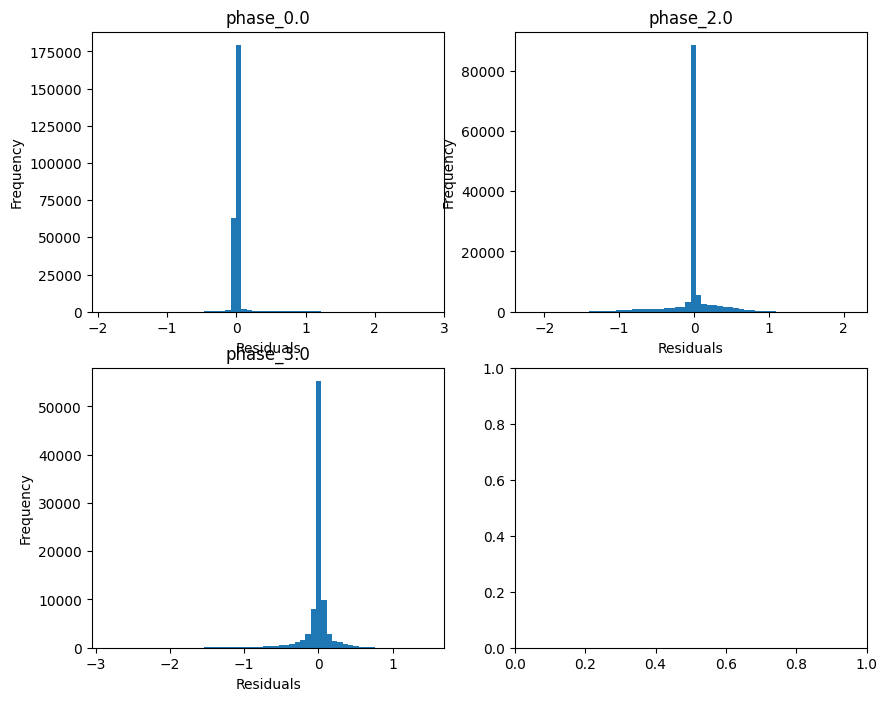

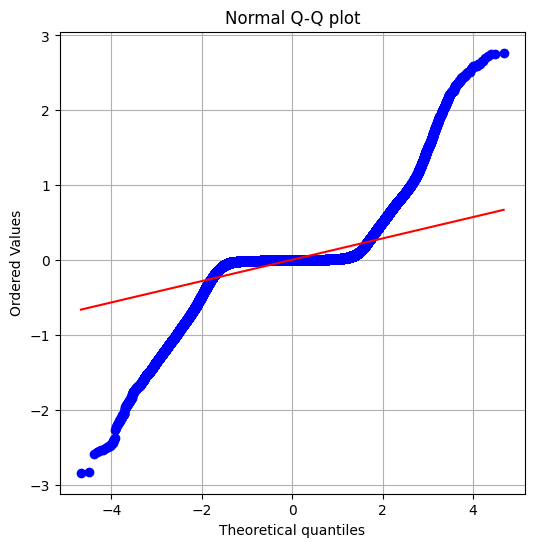

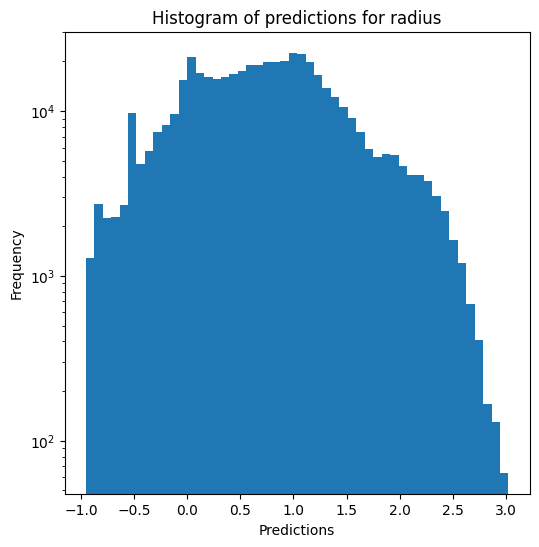

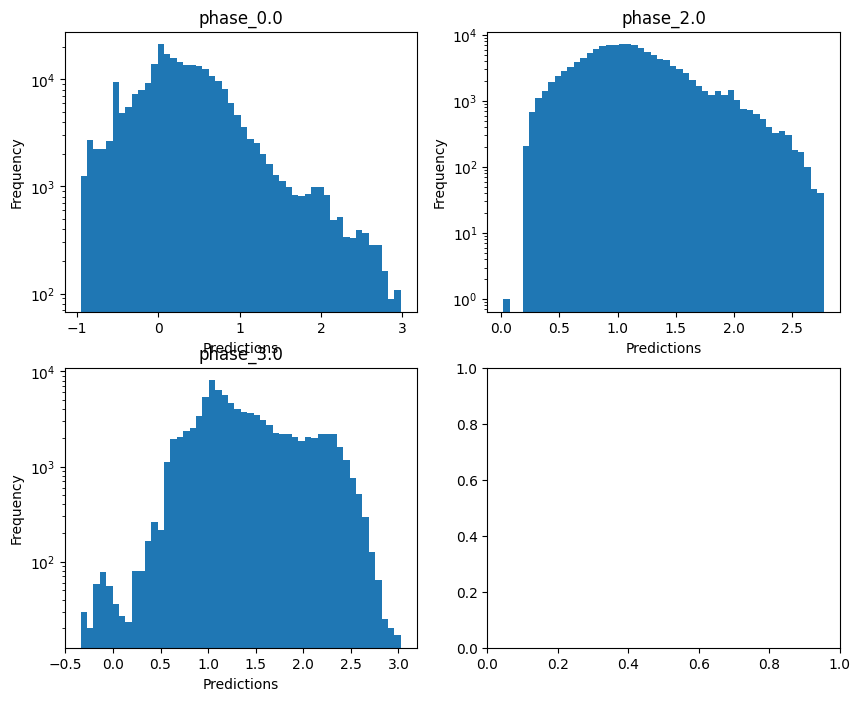

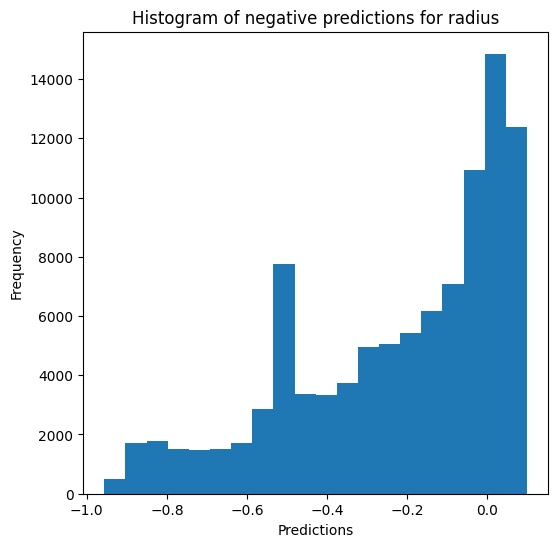

Saving predictions and results...


In [20]:
best_params_KNN = {'n_jobs' : 10, 'algorithm': 'kd_tree', 'leaf_size': 15, 'n_neighbors': 10, 'weights': 'uniform'}

print(path_to_results)
dt_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
dt_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name="quantile", **best_params_KNN)